## 1. Initial Data Understanding

### (1.1) Import Libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

from tabulate import tabulate
from pprint import pprint
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import learning_curve

### (1.2) Load Dataset and Check Basic Info

In [10]:
file_path = "C:\Bullying_2018.csv" 
df = pd.read_csv(file_path)

print("(Rows, Columns)")
print(df.shape, "\n")

print(df.info(),"\n")

print(tabulate(df.head(5), headers='keys', tablefmt='pretty'))

(Rows, Columns)
(56981, 18) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Data columns (total 18 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   record                                            56981 non-null  int64 
 1   Bullied_on_school_property_in_past_12_months      56981 non-null  object
 2   Bullied_not_on_school_property_in_past_12_months  56981 non-null  object
 3   Cyber_bullied_in_past_12_months                   56981 non-null  object
 4   Custom_Age                                        56981 non-null  object
 5   Sex                                               56981 non-null  object
 6   Physically_attacked                               56981 non-null  object
 7   Physical_fighting                                 56981 non-null  object
 8   Felt_lonely                                       56981 non-null  object
 9 

### (1.3) Initial Features Analysis

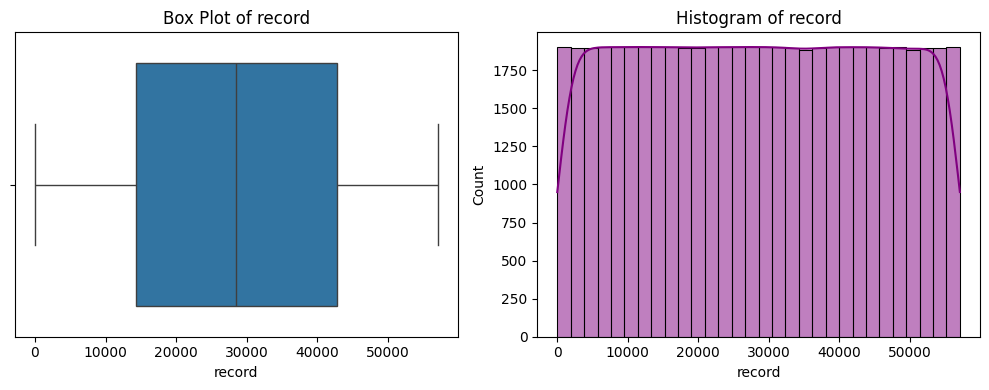

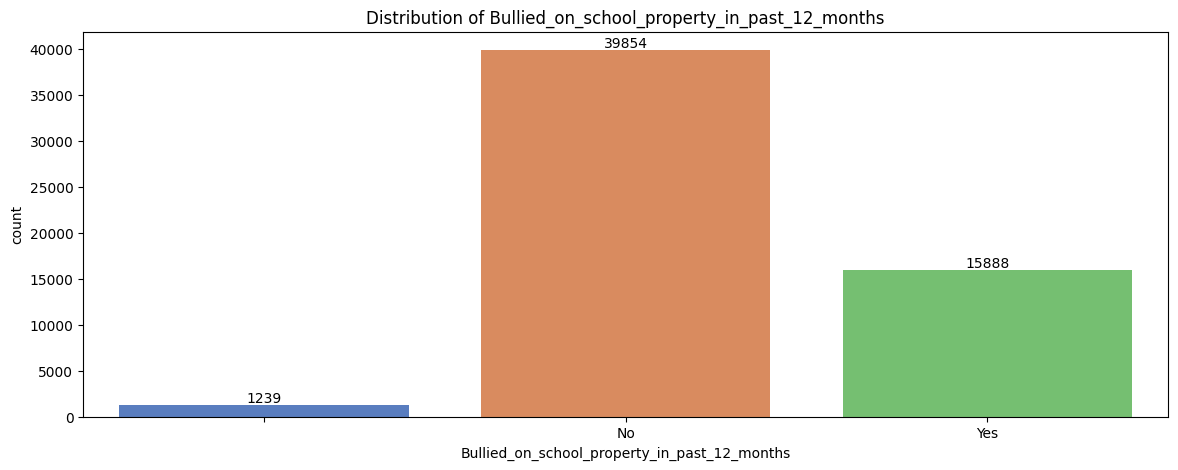

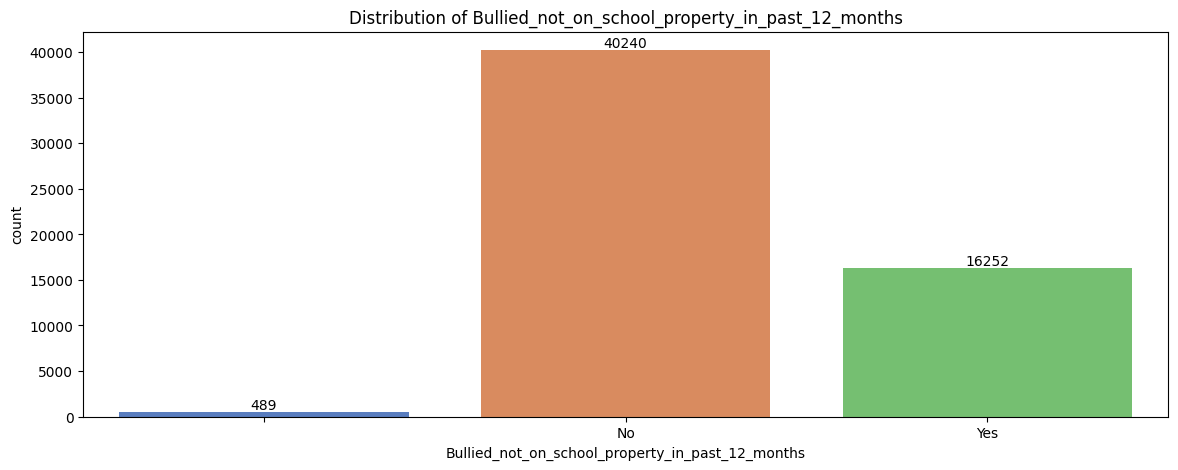

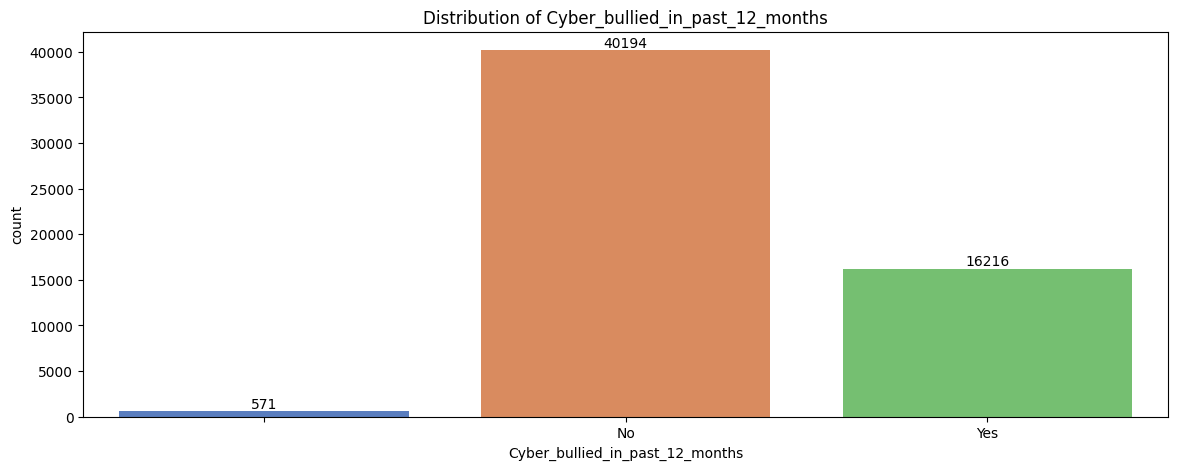

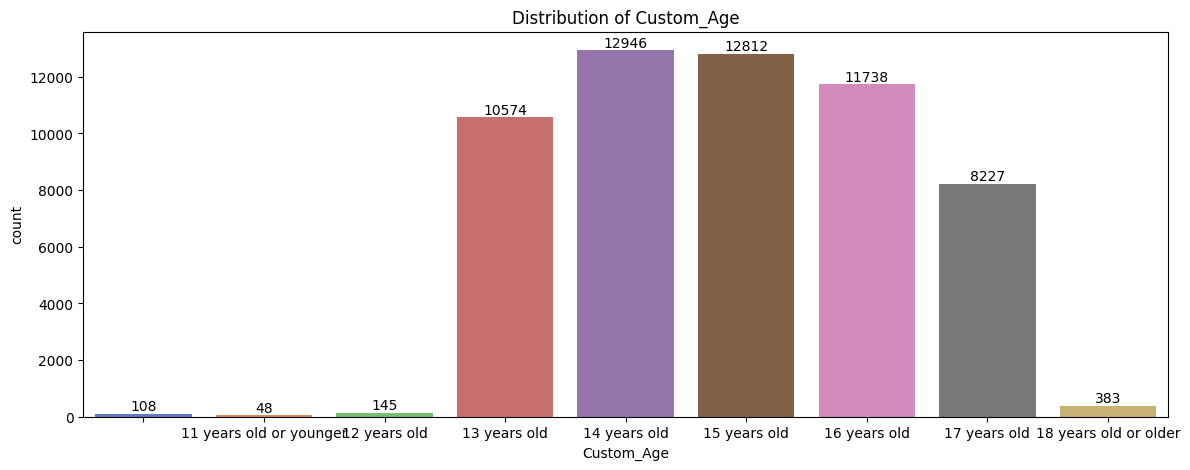

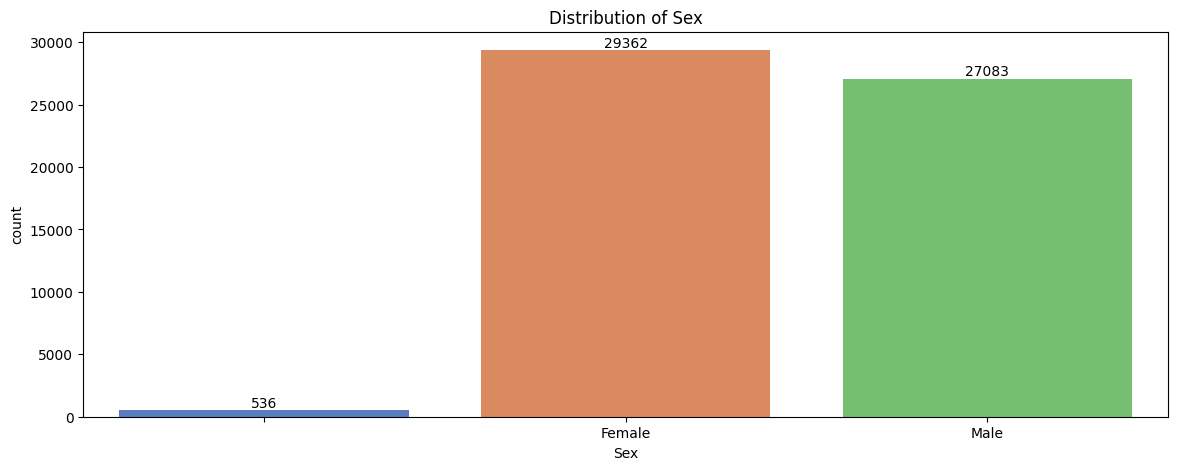

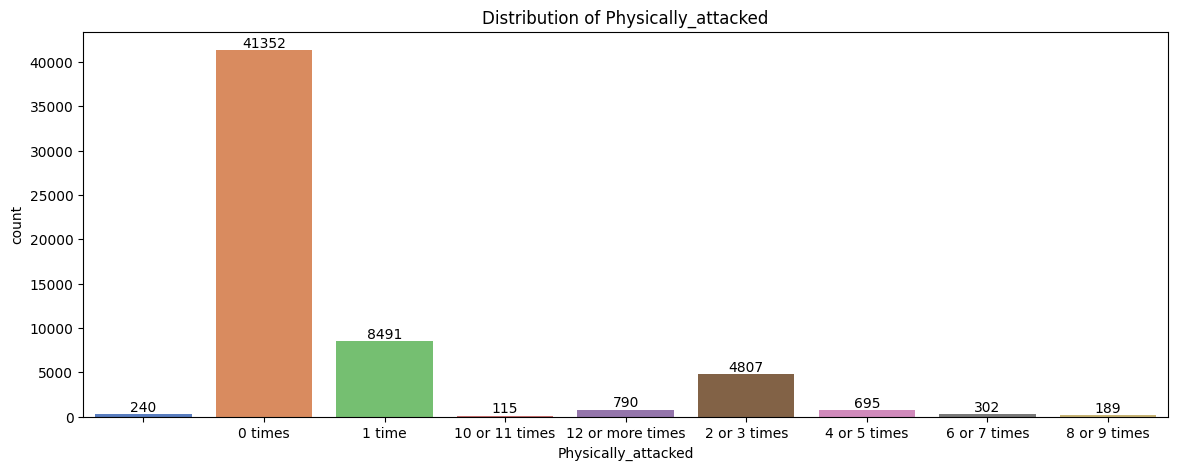

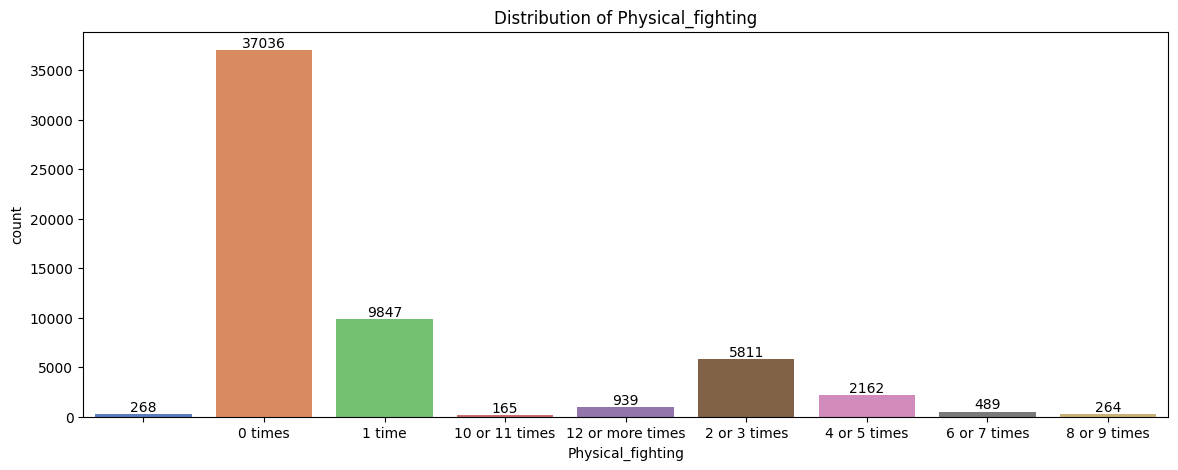

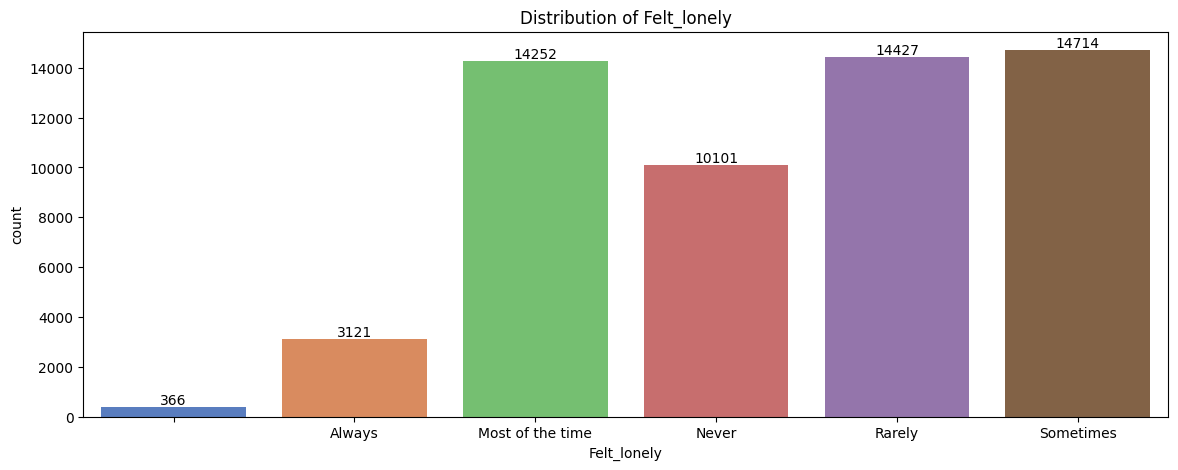

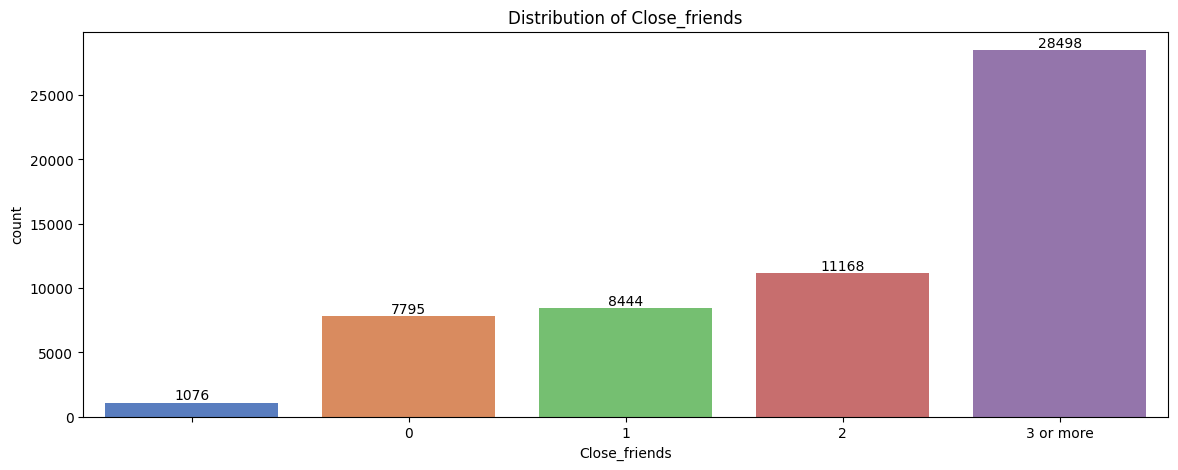

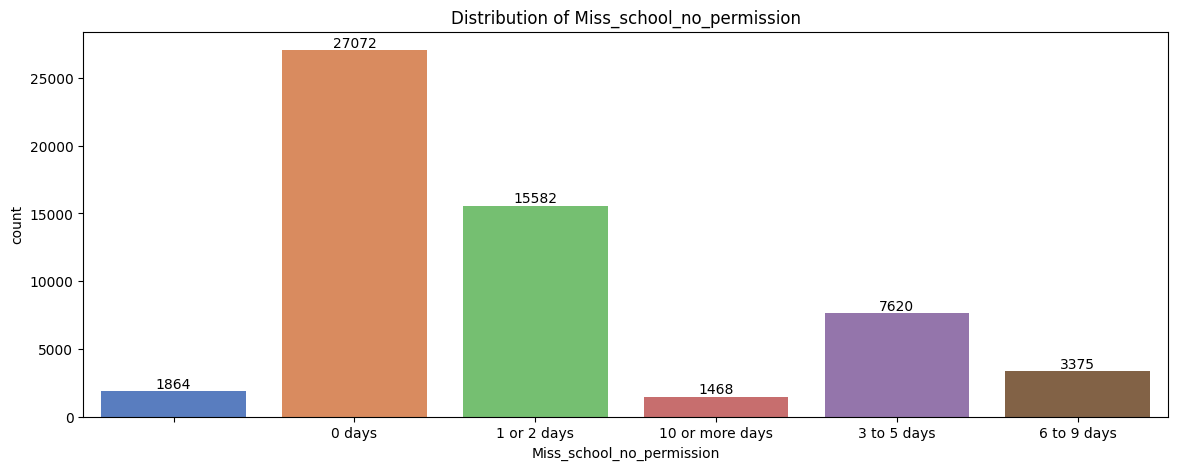

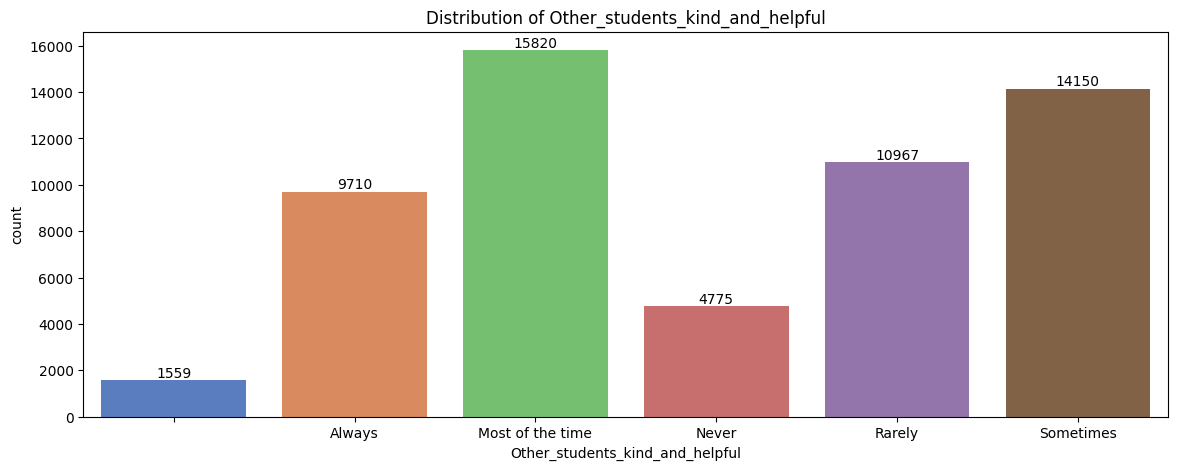

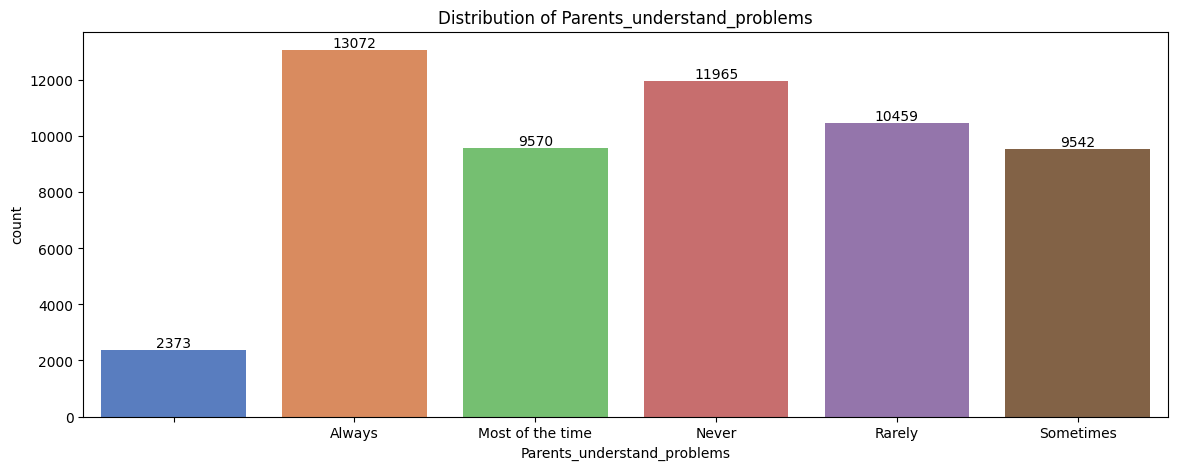

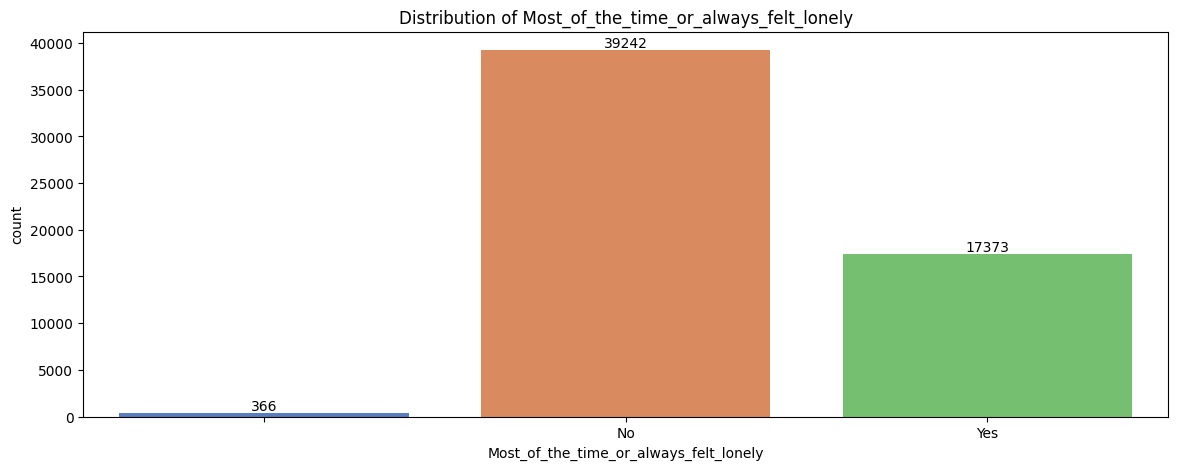

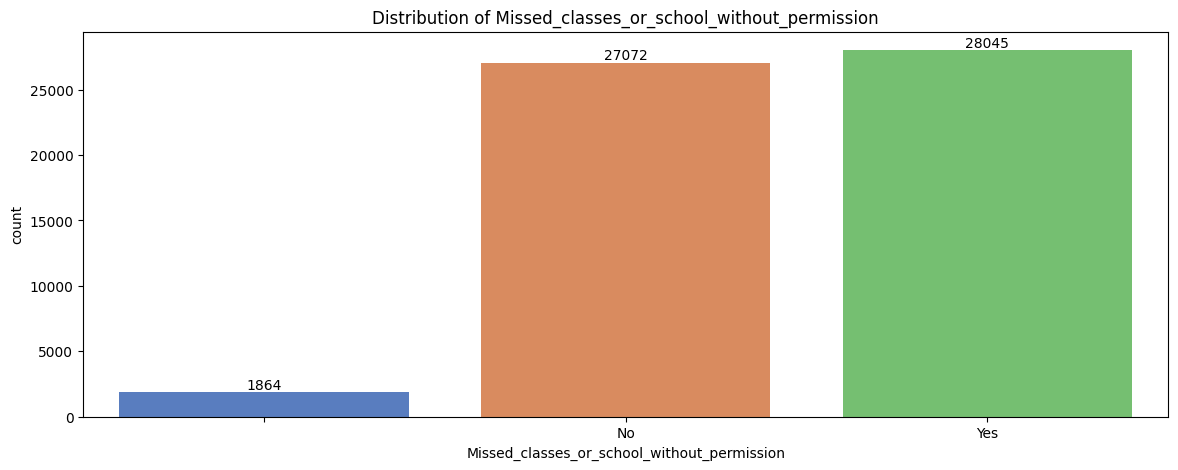

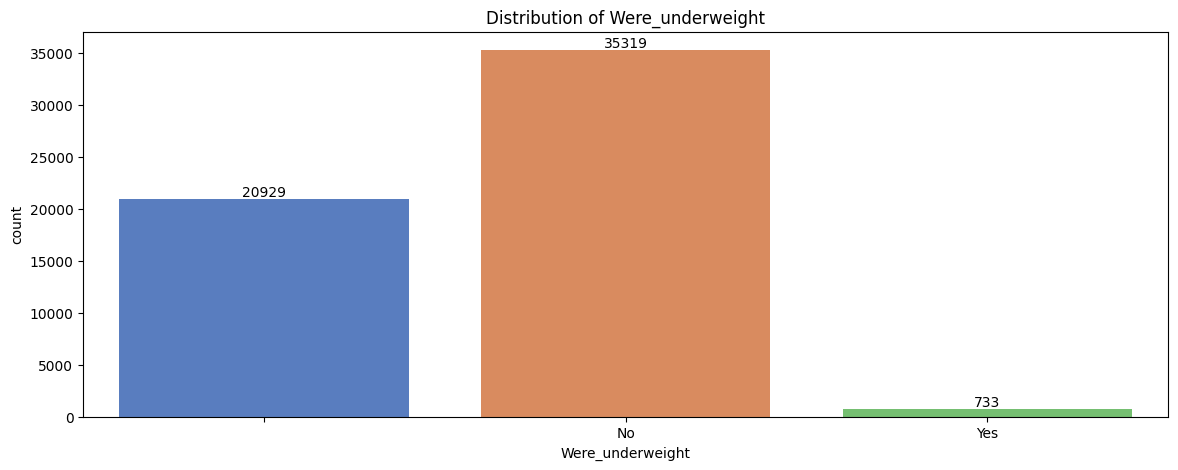

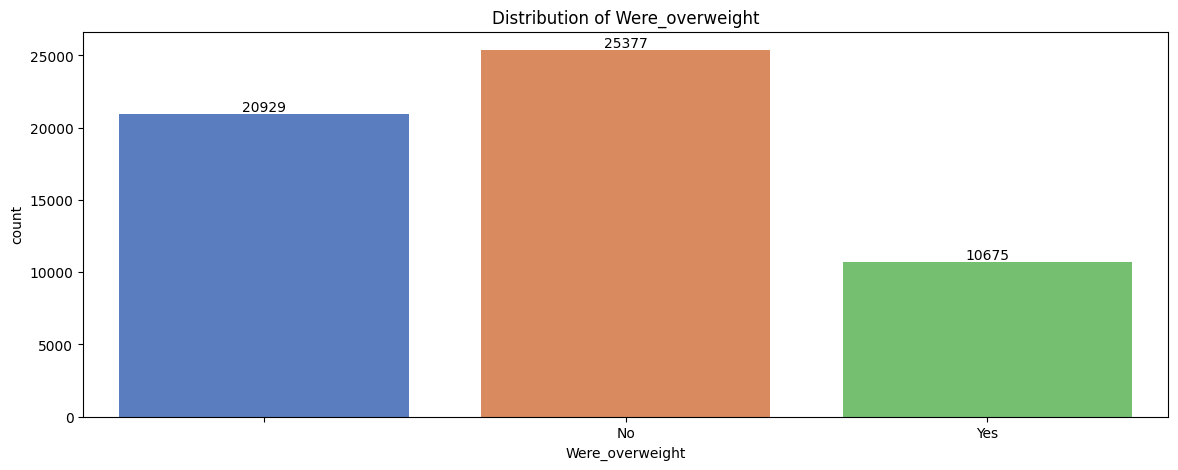

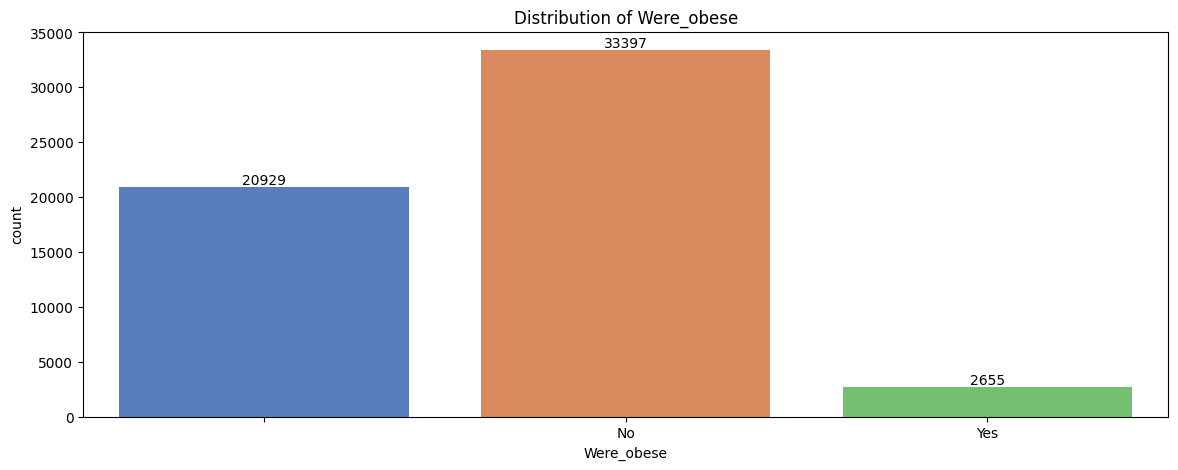

In [11]:
numeric_cols = df.select_dtypes(include=["int"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in numeric_cols:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    # Box Plot
    sns.boxplot(x=df[col], ax=axes[0])
    axes[0].set_title(f"Box Plot of {col}")

    # Histogram
    sns.histplot(df[col], bins=30, kde=True, ax=axes[1], color="purple")
    axes[1].set_title(f"Histogram of {col}")

    plt.tight_layout()
    plt.show()

for col in categorical_cols:
    unique_vals = df[col].dropna().unique()
    try:
        sorted_order = sorted(unique_vals, key=lambda x: float(x))
    except:
        # Fallback: sort alphabetically
        sorted_order = sorted(unique_vals)
    
    plt.figure(figsize=(14, 5))
    ax = sns.countplot(
        x=df[col], 
        hue=df[col], 
        palette="muted",
        order=sorted_order,
        hue_order=sorted_order,
    )
    
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}',  
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='bottom', fontsize=10, color='black'
        )
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=0)
    plt.show()

### (1.4) Check Missing Value

In [12]:
df_csv = pd.read_csv(file_path, dtype=str, na_values=["", " "])

# Calculate missing count and percentage
missing_count = df_csv.isnull().sum()
missing_percentage = (missing_count / len(df_csv)) * 100

missing_info = missing_count[missing_count > 0].astype(str) + " (" + missing_percentage[missing_percentage > 0].round(2).astype(str) + "%)"
print("Number of Missing Value:")
print("------------------------------------------------------------------")
print(missing_info)

Number of Missing Value:
------------------------------------------------------------------
Bullied_on_school_property_in_past_12_months          1239 (2.17%)
Bullied_not_on_school_property_in_past_12_months       489 (0.86%)
Cyber_bullied_in_past_12_months                         571 (1.0%)
Custom_Age                                             108 (0.19%)
Sex                                                    536 (0.94%)
Physically_attacked                                    240 (0.42%)
Physical_fighting                                      268 (0.47%)
Felt_lonely                                            366 (0.64%)
Close_friends                                         1076 (1.89%)
Miss_school_no_permission                             1864 (3.27%)
Other_students_kind_and_helpful                       1559 (2.74%)
Parents_understand_problems                           2373 (4.16%)
Most_of_the_time_or_always_felt_lonely                 366 (0.64%)
Missed_classes_or_school_without_perm

### (1.5) Check Inconsistence Value 

In [13]:
columns_to_check = [
    "Physically_attacked",
    "Physical_fighting",
    "Close_friends",
    "Miss_school_no_permission"
]

unique_values = {col: df[col].unique().tolist() for col in columns_to_check}
pprint(unique_values)


{'Close_friends': ['2', '3 or more', '0', '1', ' '],
 'Miss_school_no_permission': ['10 or more days',
                               '6 to 9 days',
                               '0 days',
                               '3 to 5 days',
                               ' ',
                               '1 or 2 days'],
 'Physical_fighting': ['0 times',
                       '2 or 3 times',
                       '1 time',
                       '4 or 5 times',
                       '6 or 7 times',
                       '8 or 9 times',
                       '10 or 11 times',
                       ' ',
                       '12 or more times'],
 'Physically_attacked': ['2 or 3 times',
                         '0 times',
                         '1 time',
                         '12 or more times',
                         '4 or 5 times',
                         '10 or 11 times',
                         '8 or 9 times',
                         '6 or 7 times',
                      

### (1.6) Check Outliers

In [14]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
print("Outliers Count:")
print(outliers)

Outliers Count:
record    0
dtype: int64


## 2. Data Pre-processing (1)

### (2.1) Rename Variables

In [15]:
rename_mapping = {
    "record": "Record",
    "Bullied_on_school_property_in_past_12_months": "Bullied_in_school",
    "Bullied_not_on_school_property_in_past_12_months": "Bullied_not_in_school",
    "Cyber_bullied_in_past_12_months": "Cyberbullied",
    "Custom_Age": "Age",
    "Sex": "Gender",
    "Miss_school_no_permission": "Missed_school",
    "Other_students_kind_and_helpful": "Peer_helpfulness",
    "Parents_understand_problems": "Parental_understanding"
}
df.rename(columns=rename_mapping, inplace=True)
df.columns
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Data columns (total 18 columns):
 #   Column                                       Non-Null Count  Dtype 
---  ------                                       --------------  ----- 
 0   Record                                       56981 non-null  int64 
 1   Bullied_in_school                            56981 non-null  object
 2   Bullied_not_in_school                        56981 non-null  object
 3   Cyberbullied                                 56981 non-null  object
 4   Age                                          56981 non-null  object
 5   Gender                                       56981 non-null  object
 6   Physically_attacked                          56981 non-null  object
 7   Physical_fighting                            56981 non-null  object
 8   Felt_lonely                                  56981 non-null  object
 9   Close_friends                                56981 non-null  object
 10  Missed_sch

### (2.2) Hnadling Missing Value

In [ ]:
# replace empty cell to null value
df.replace(r'^\s*$', pd.NA, regex=True, inplace=True)
df.fillna({"column_name": "default_value"}, inplace=True) 


# 1. Yes/No data: Assume "Yes" 
yes_no_columns = [
    "Bullied_in_school", "Bullied_not_in_school",
    "Cyberbullied", "Most_of_the_time_or_always_felt_lonely",
    "Missed_classes_or_school_without_permission",
    "Were_overweight", "Were_obese"
]
df[yes_no_columns] = df[yes_no_columns].fillna("Yes")
df["Were_underweight"] = df["Were_underweight"].fillna("No")


# 2. Physically_attack & Physical_fighting: Assume "0 times" 
attack_columns = ["Physically_attacked", "Physical_fighting"]
df[attack_columns] = df[attack_columns].fillna("0 times")


# 3. Close_friends: Assume "0" 
df["Close_friends"] = df["Close_friends"].fillna("0")


# 4. Miss_school: Assume "0 days" 
df["Missed_school"] = df["Missed_school"].fillna("0 days")


# 5. Age: Extract numerical values , calculate median, reformat as string
numeric_age = df["Age"].str.extract('(\d+)').astype(float)
median_age = numeric_age.median()  # Calculate median
df["Age"] = df["Age"].fillna(f"{int(median_age)} years old")


# 6. Gender: Use mode
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])


# 7. Never-Always data: Assume "Never" 
never_always_columns = [
    "Peer_helpfulness",
    "Parental_understanding"
]
df[never_always_columns] = df[never_always_columns].fillna("Never")
df["Felt_lonely"] = df["Felt_lonely"].fillna("Always")


print("Number of Missing Value After Handle:")
print("---------------------------------------------------")
print(df.isnull().sum(),"\n")
print(tabulate(df.head(10), headers='keys', tablefmt='pretty'))

Number of Missing Value After Handle:
---------------------------------------------------
Record                                         0
Bullied_in_school                              0
Bullied_not_in_school                          0
Cyberbullied                                   0
Age                                            0
Gender                                         0
Physically_attacked                            0
Physical_fighting                              0
Felt_lonely                                    0
Close_friends                                  0
Missed_school                                  0
Peer_helpfulness                               0
Parental_understanding                         0
Most_of_the_time_or_always_felt_lonely         0
Missed_classes_or_school_without_permission    0
Were_underweight                               0
Were_overweight                                0
Were_obese                                     0
dtype: int64 

+---+--------

C:\Users\Yap\AppData\Local\Temp\ipykernel_38108\628260939.py:36: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  df["Age"] = df["Age"].fillna(f"{int(median_age)} years old")


### (2.3) Feature Engineering
- Combine 3 classification of bullied

In [17]:
# Combine & Create "Bullied"
df["Bullied"] = df[["Bullied_in_school", 
                    "Bullied_not_in_school", 
                    "Cyberbullied"]].max(axis=1)

columns_to_remove = ["Bullied_in_school", 
                     "Bullied_not_in_school", 
                     "Cyberbullied"]
df.drop(columns=columns_to_remove, inplace=True)

# Reorder columns
cols = list(df.columns)
cols.remove("Bullied")

if "Record" in cols:
    first_two_cols = ["Record"]
    remaining_cols = [col for col in cols if col != "Record"]
    new_order = first_two_cols + ["Bullied"] + remaining_cols 
    df = df[new_order]

print("(Rows, Columns)")
print(df.shape, "\n")

print(df.info(),"\n")
print(tabulate(df.head(10), headers='keys', tablefmt='pretty'))

(Rows, Columns)
(56981, 16) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Data columns (total 16 columns):
 #   Column                                       Non-Null Count  Dtype 
---  ------                                       --------------  ----- 
 0   Record                                       56981 non-null  int64 
 1   Bullied                                      56981 non-null  object
 2   Age                                          56981 non-null  object
 3   Gender                                       56981 non-null  object
 4   Physically_attacked                          56981 non-null  object
 5   Physical_fighting                            56981 non-null  object
 6   Felt_lonely                                  56981 non-null  object
 7   Close_friends                                56981 non-null  object
 8   Missed_school                                56981 non-null  object
 9   Peer_helpfulness                             56981 no

### (2.4) Remove Redundant Data

In [18]:
columns_to_remove = ["Record", 
                     "Most_of_the_time_or_always_felt_lonely", 
                     "Missed_classes_or_school_without_permission" 
                     ]
df.drop(columns=columns_to_remove, inplace=True)

print("(Rows, Columns)")
print(df.shape, "\n")

print(df.info(),"\n")
print(tabulate(df.head(10), headers='keys', tablefmt='pretty'))

(Rows, Columns)
(56981, 13) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Bullied                 56981 non-null  object
 1   Age                     56981 non-null  object
 2   Gender                  56981 non-null  object
 3   Physically_attacked     56981 non-null  object
 4   Physical_fighting       56981 non-null  object
 5   Felt_lonely             56981 non-null  object
 6   Close_friends           56981 non-null  object
 7   Missed_school           56981 non-null  object
 8   Peer_helpfulness        56981 non-null  object
 9   Parental_understanding  56981 non-null  object
 10  Were_underweight        56981 non-null  object
 11  Were_overweight         56981 non-null  object
 12  Were_obese              56981 non-null  object
dtypes: object(13)
memory usage: 5.7+ MB
None 

+---+---------+--------------+---

## 2b Features Analysis (after pre-processing 1)

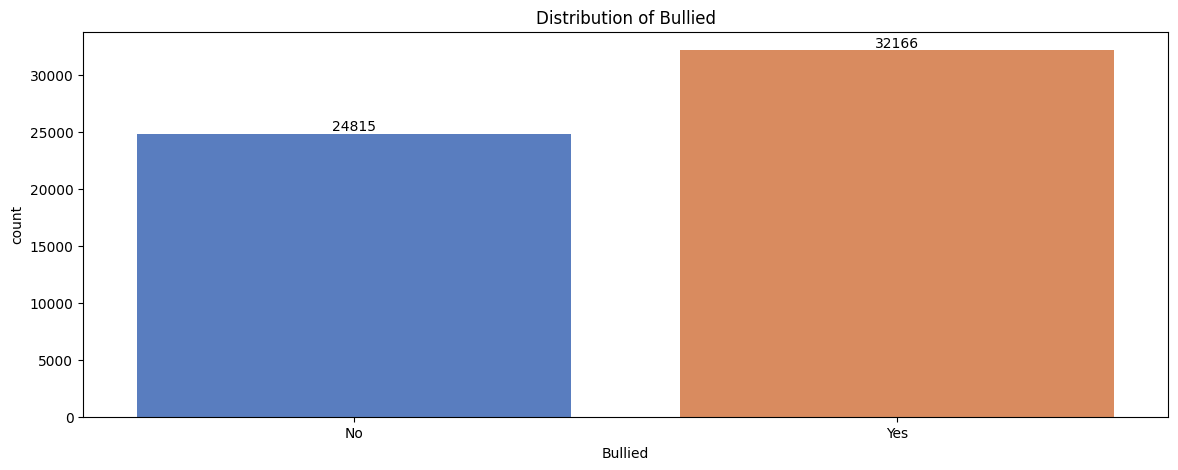

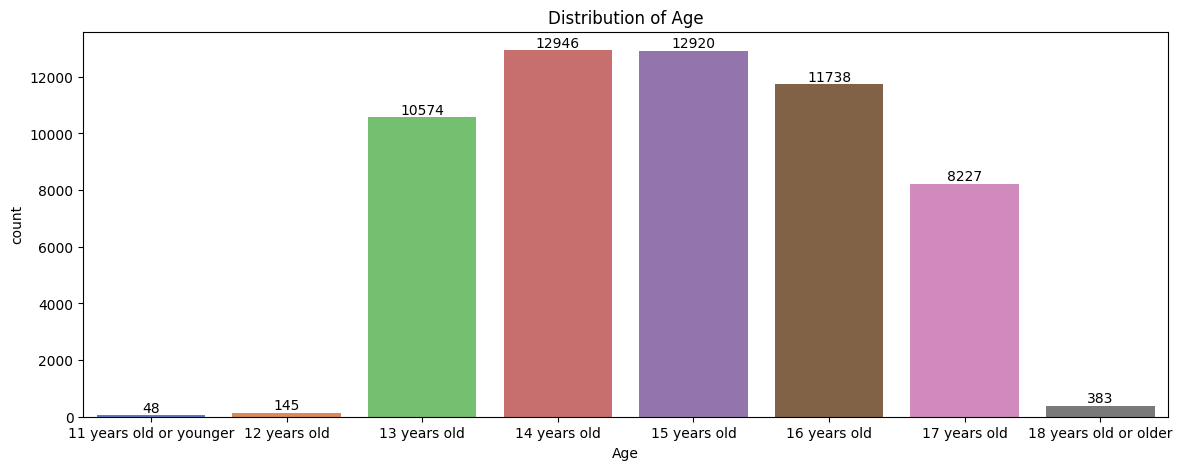

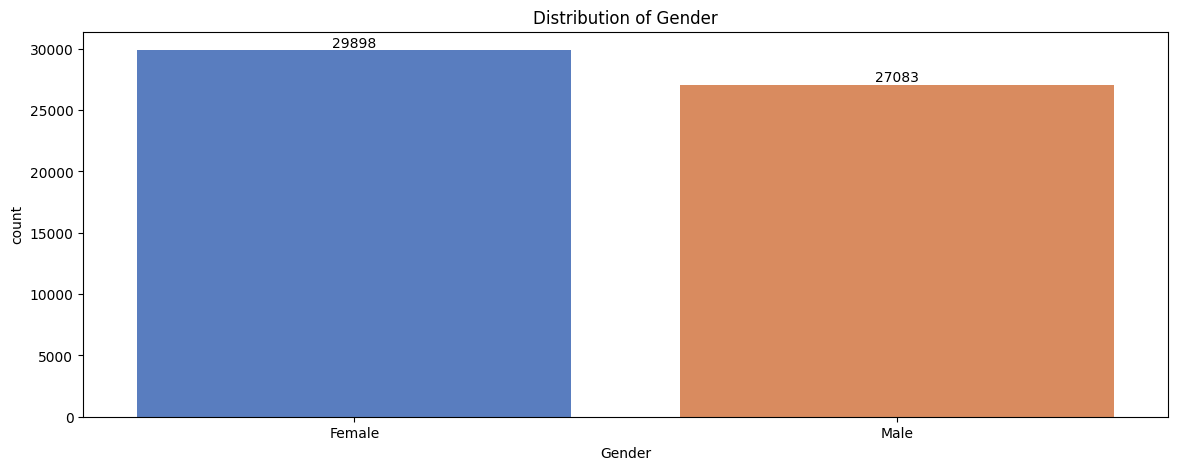

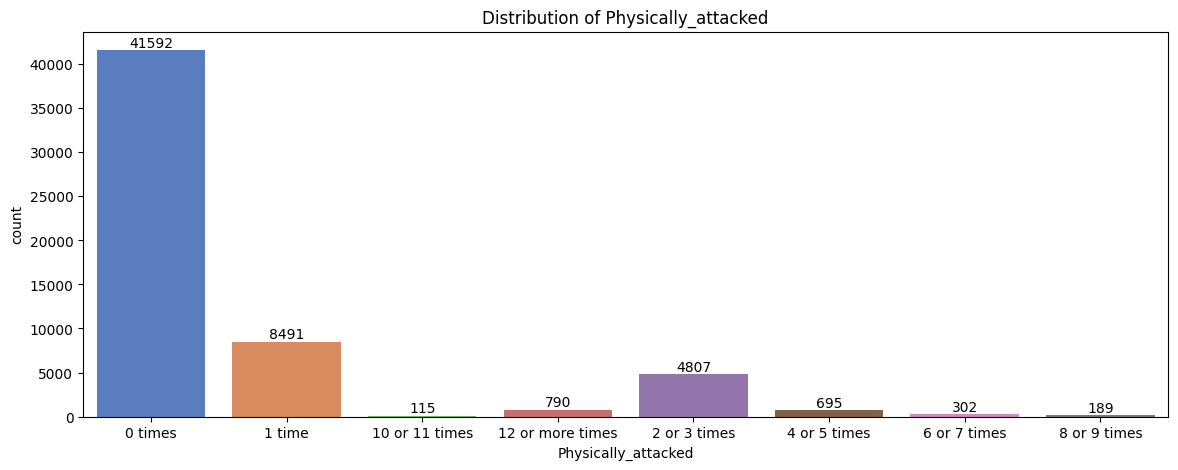

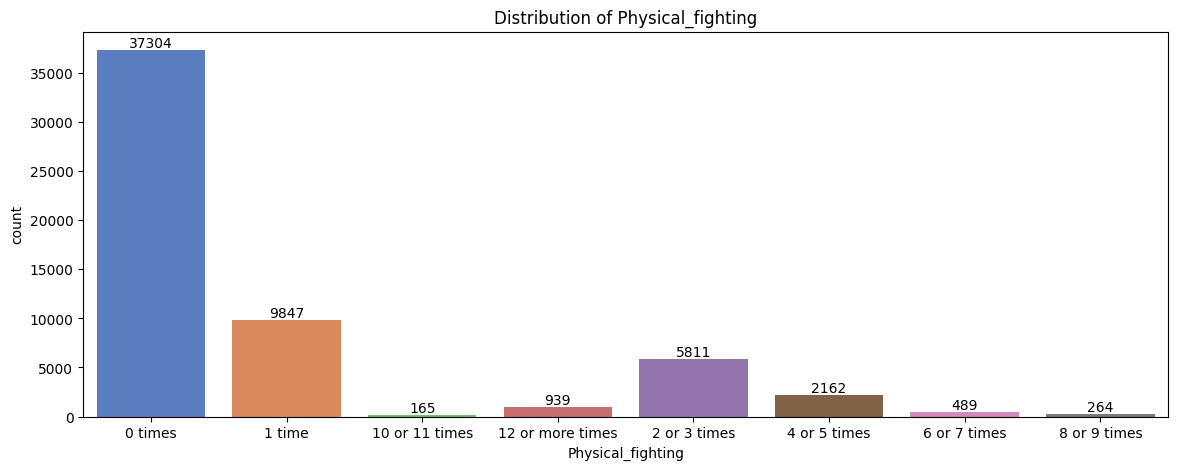

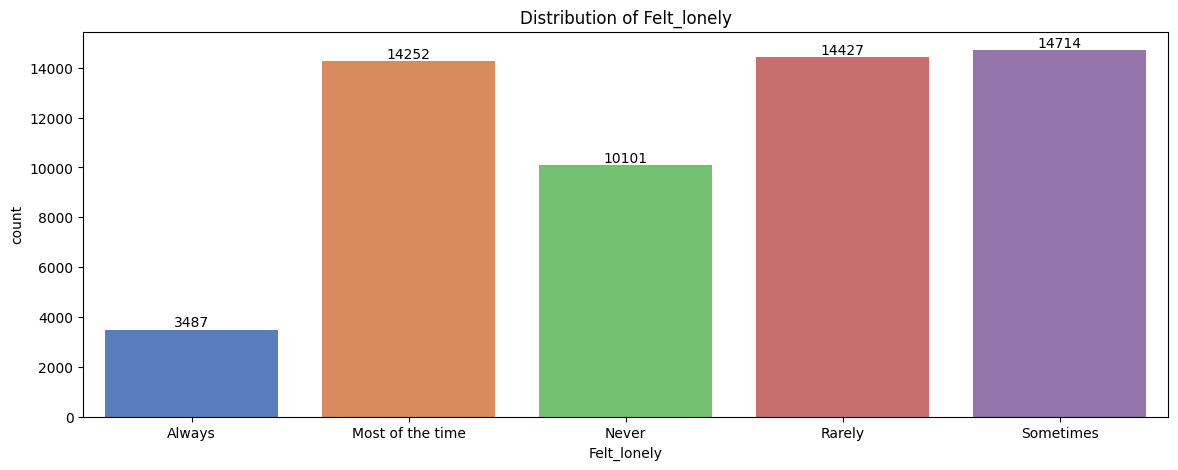

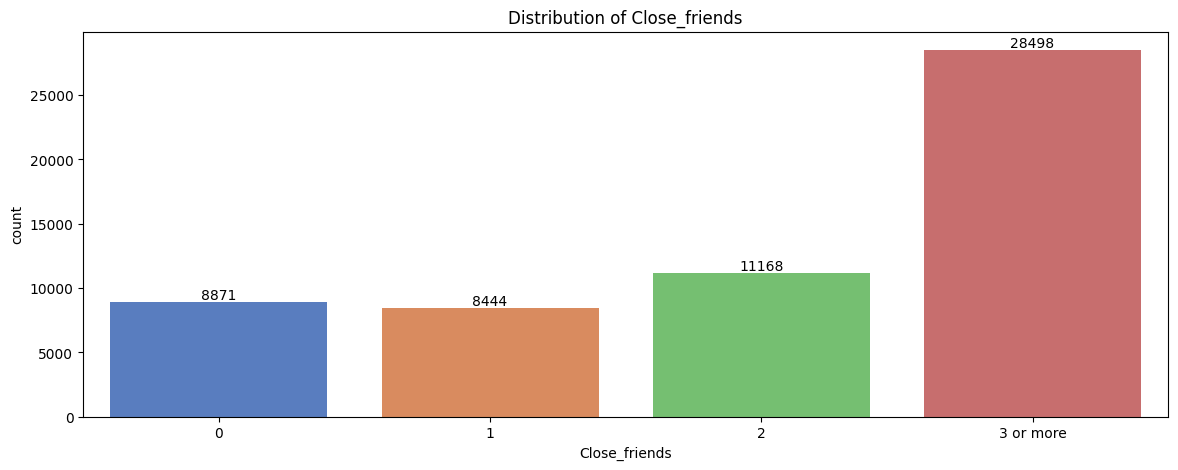

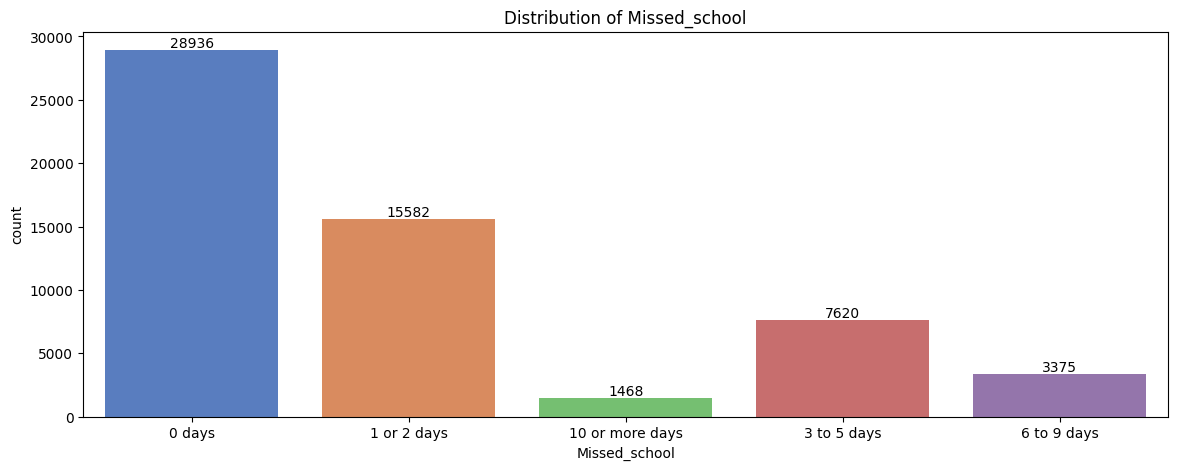

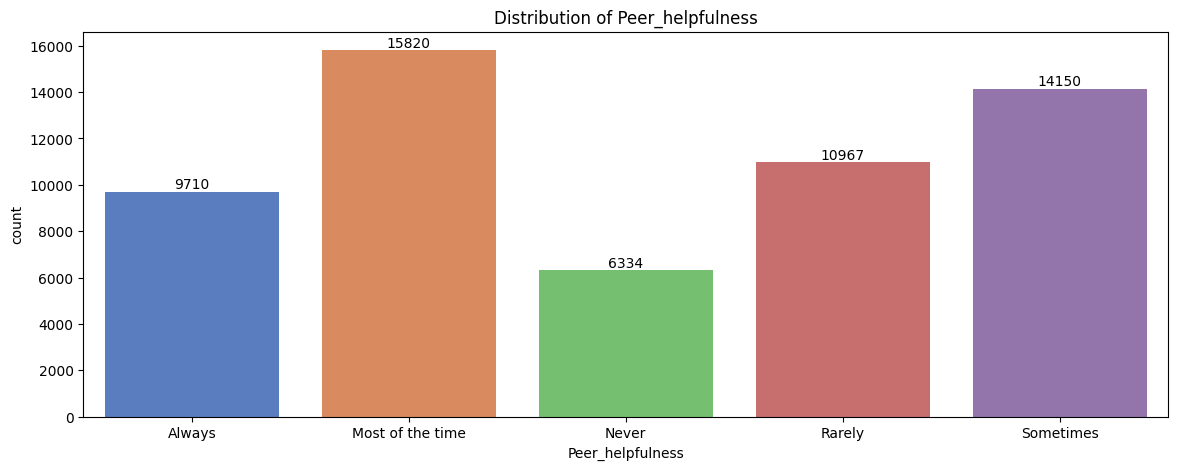

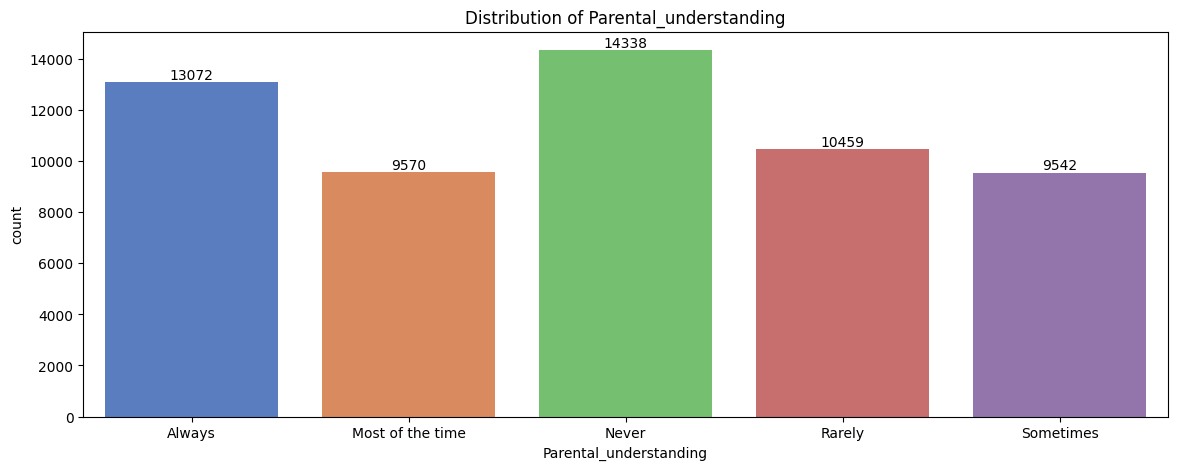

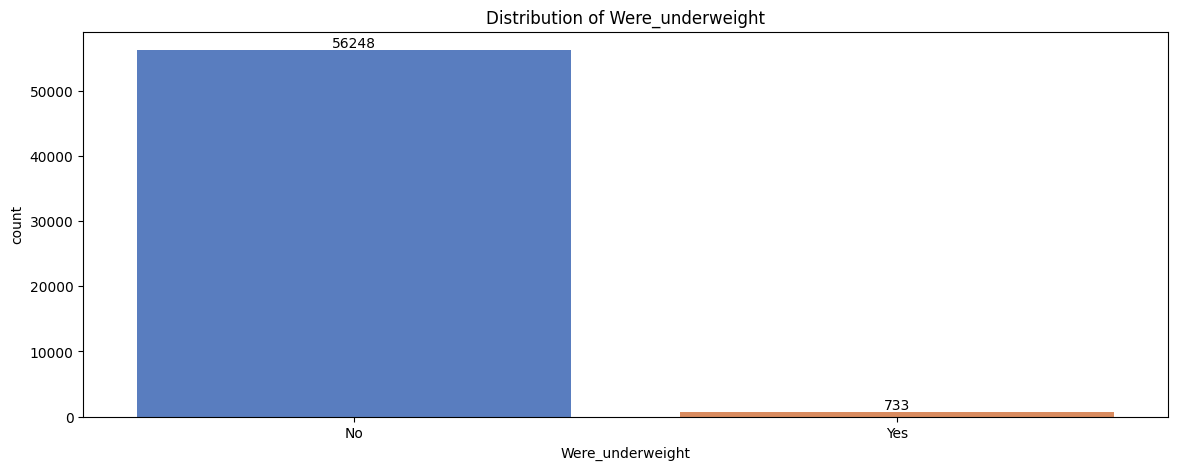

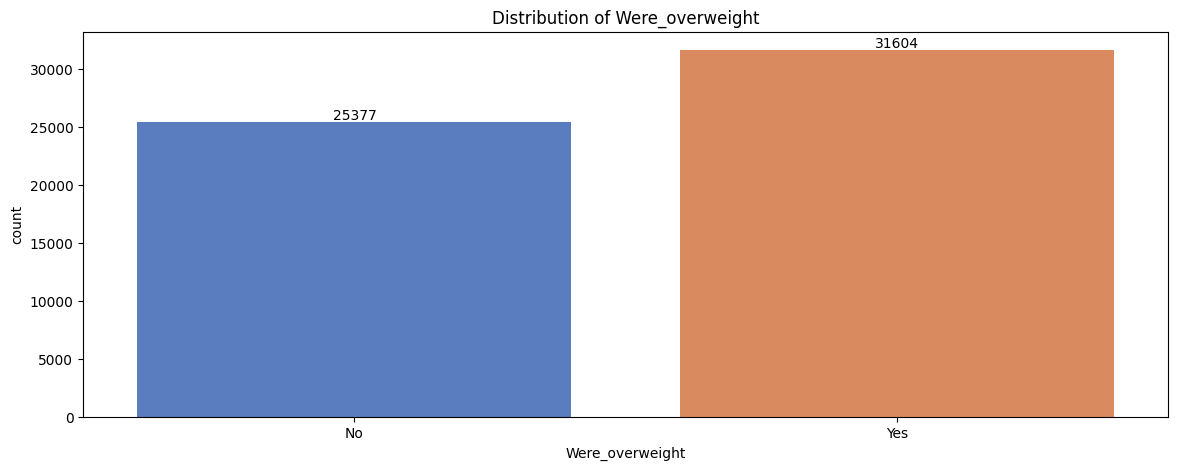

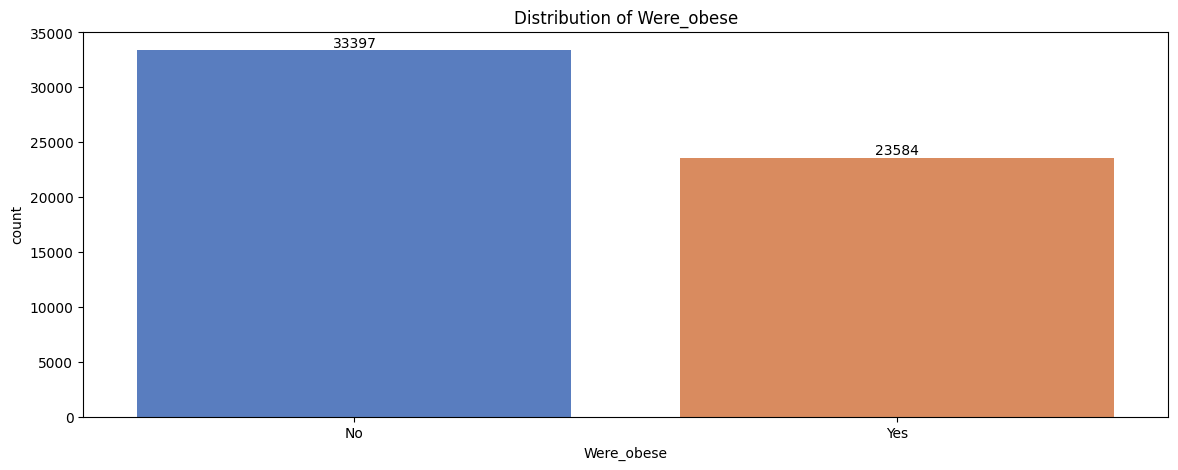

In [19]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    unique_vals = df[col].dropna().unique()
    try:
        sorted_order = sorted(unique_vals, key=lambda x: float(x))
    except:
        # Fallback: sort alphabetically
        sorted_order = sorted(unique_vals)

    plt.figure(figsize=(14, 5))
    ax = sns.countplot(
        x=df[col], 
        hue=df[col], 
        palette="muted",
        order=sorted_order,
        hue_order=sorted_order,
    )
    
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}',  
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='bottom', fontsize=10, color='black'
        )
        
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=0)
    plt.show()

## 3. Data Pre-processing (2)

### (3.1) Data Transformation

- Extract Numbers only


In [20]:
# Convert "Age" column to keep only numbers 
df["Age"] = df["Age"].str.extract("(\d+)").astype(float).fillna(0).astype(int)

def extract_first_number(value):
    """Extracts the first numeric value from a string and converts it to int."""
    match = re.search(r'\d+', str(value))  
    return int(match.group()) if match else None  


# For ordinal columns, replace null with 0, then convert to int
ordinal_cols = ["Physically_attacked", 
                "Physical_fighting", 
                "Close_friends", 
                "Missed_school"]
df[ordinal_cols] = df[ordinal_cols].apply(lambda col: col.map(extract_first_number)).fillna(0).astype(int)

- Yes/No → 1/0
- Scale Mapping (Never - Always → 1-5)
- Gender Mapping (Female=0, Male=1)

In [21]:
# Yes/No → 1/0
Yes_No_col = ["Bullied", 
              "Were_underweight", 
              "Were_overweight", 
              "Were_obese"]
for col in Yes_No_col:
    df[col] = df[col].map({"Yes": 1, "No": 0})


# Scale Mapping (Never - Always -> 1-5)
scale_cols = ["Felt_lonely", 
              "Peer_helpfulness", 
              "Parental_understanding"]

scale_map = {"Never": 1, 
             "Rarely": 2, 
             "Sometimes": 3, 
             "Most of the time": 4, 
             "Always": 5}
df[scale_cols] = df[scale_cols].replace(scale_map)


# Gender Mapping (Female=0, Male=1)
df["Gender"] = df["Gender"].map({"Female": 0, 
                                 "Male": 1})

print(df.info(),"\n")
print(tabulate(df.head(10), headers='keys', tablefmt='pretty'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Bullied                 56981 non-null  int64
 1   Age                     56981 non-null  int64
 2   Gender                  56981 non-null  int64
 3   Physically_attacked     56981 non-null  int64
 4   Physical_fighting       56981 non-null  int64
 5   Felt_lonely             56981 non-null  int64
 6   Close_friends           56981 non-null  int64
 7   Missed_school           56981 non-null  int64
 8   Peer_helpfulness        56981 non-null  int64
 9   Parental_understanding  56981 non-null  int64
 10  Were_underweight        56981 non-null  int64
 11  Were_overweight         56981 non-null  int64
 12  Were_obese              56981 non-null  int64
dtypes: int64(13)
memory usage: 5.7 MB
None 

+---+---------+-----+--------+---------------------+-------------------+--------

C:\Users\Yap\AppData\Local\Temp\ipykernel_38108\1981007331.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[scale_cols] = df[scale_cols].replace(scale_map)


## 4. Data Understanding (After Pre-processing)

### (4.1) Check Outliers (After Pre-processing)

In [22]:
numeric_cols = df.select_dtypes(include=[int]).columns

# Calculate outlier count 
outliers_count = {}
for col in df[numeric_cols]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count[col] = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

# Print the count of outliers 
print(f"{'Column name':<29}{'Outliers'}")
print("-" * 40)
for column, count in outliers_count.items():
    print(f"{column:<30}{count}")

Column name                  Outliers
----------------------------------------
Bullied                       0
Age                           0
Gender                        0
Physically_attacked           2091
Physical_fighting             4019
Felt_lonely                   0
Close_friends                 0
Missed_school                 12463
Peer_helpfulness              0
Parental_understanding        0
Were_underweight              733
Were_overweight               0
Were_obese                    0


### (4.2) Create new column for outliers

In [23]:
numeric_cols = df.select_dtypes(include='number').columns

# Precompute IQR bounds
bounds = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    bounds[col] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# Check outliers in a row
def detect_outliers(row):
    for col in numeric_cols:
        lower, upper = bounds[col]
        if row[col] < lower or row[col] > upper:
            return 1
    return 0

# Create new column "Has_Outlier"
df["Has_Outlier"] = df.apply(detect_outliers, axis=1)

print("(Rows, Columns)")
print(df.shape, "\n")
print(tabulate(df.head(10), headers='keys', tablefmt='pretty'))


(Rows, Columns)
(56981, 14) 

+---+---------+-----+--------+---------------------+-------------------+-------------+---------------+---------------+------------------+------------------------+------------------+-----------------+------------+-------------+
|   | Bullied | Age | Gender | Physically_attacked | Physical_fighting | Felt_lonely | Close_friends | Missed_school | Peer_helpfulness | Parental_understanding | Were_underweight | Were_overweight | Were_obese | Has_Outlier |
+---+---------+-----+--------+---------------------+-------------------+-------------+---------------+---------------+------------------+------------------------+------------------+-----------------+------------+-------------+
| 0 |    1    | 13  |   0    |          2          |         0         |      5      |       2       |      10       |        1         |           5            |        0         |        1        |     1      |      1      |
| 1 |    1    | 13  |   0    |          0          |         0

### (4.3) Correlation Heatmap

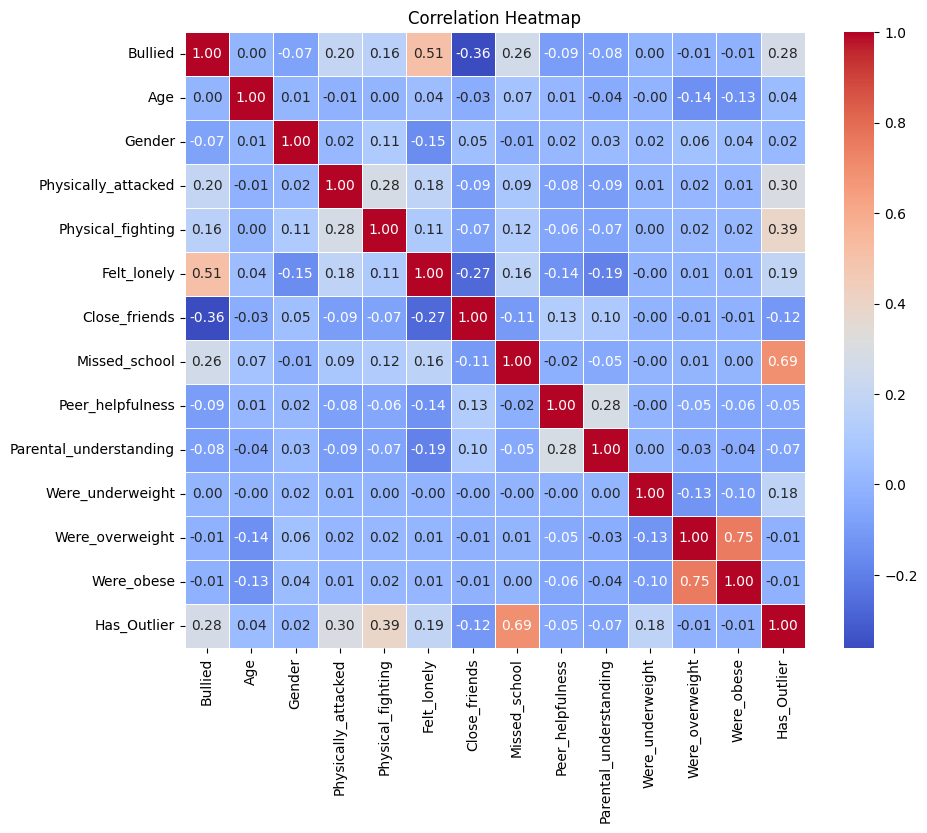

In [24]:
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [25]:
df_clean = df

## 5. Data Modelling

### (5.1) Check Target Variable count

In [26]:
print(df_clean['Bullied'].value_counts())

Bullied
1    32166
0    24815
Name: count, dtype: int64


### (5.2) Split Data (Train & Test)

In [27]:
X = df_clean.drop('Bullied', axis=1)
y = df_clean['Bullied'] 

# Split into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Training Set
print("[Train] Set Shape:")
train_count = y_train.value_counts()
print(train_count)
print("Total:", train_count.sum(), "\n")

#Testing Set
print("[Test] Set Shape:")
test_count = y_test.value_counts()
print(test_count)
print("Total:", test_count.sum(), "\n")

[Train] Set Shape:
Bullied
1    25696
0    19888
Name: count, dtype: int64
Total: 45584 

[Test] Set Shape:
Bullied
1    6470
0    4927
Name: count, dtype: int64
Total: 11397 



## 6. Model building & Evaluation

#### (6.1) Logistic Regression (LR)

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Optionally scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model
log_reg_model = LogisticRegression(max_iter=200)
log_reg_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_log_reg = log_reg_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred_log_reg)
confusion = confusion_matrix(y_test, y_pred_log_reg)
report = classification_report(y_test, y_pred_log_reg)

# Print results
print(f"Confusion Matrix:\n {confusion}")
print(f"\n📊 Classification Report:\n{report}")
print(f"✅ Accuracy: {accuracy:.4f}")


Confusion Matrix:
 [[3749 1178]
 [1095 5375]]

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.77      4927
           1       0.82      0.83      0.83      6470

    accuracy                           0.80     11397
   macro avg       0.80      0.80      0.80     11397
weighted avg       0.80      0.80      0.80     11397

✅ Accuracy: 0.8006


##### LR - Learning Curve (Base)

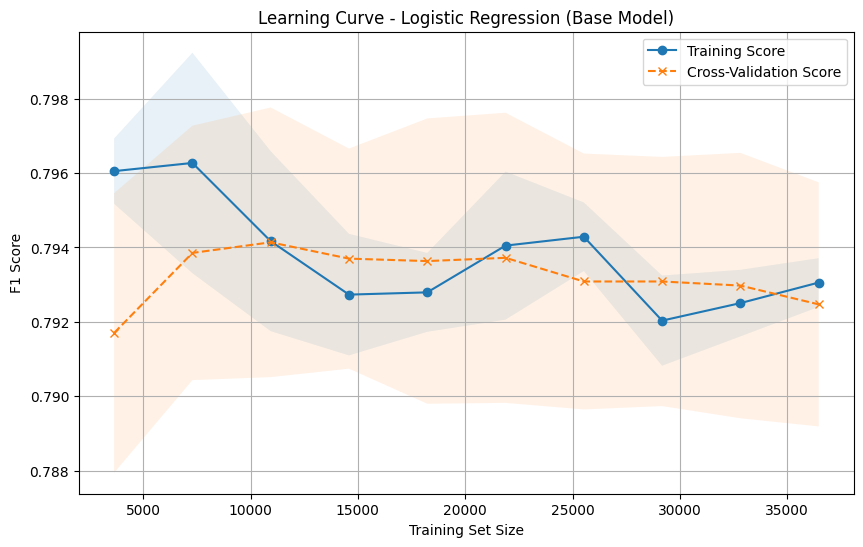

In [31]:
from sklearn.model_selection import learning_curve

# Base model (Logistic Regression) learning curve
train_sizes, train_scores, test_scores = learning_curve(
    log_reg_model, 
    X_train_scaled, 
    y_train, 
    cv=5, 
    n_jobs=-1, 
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
)

# Calculate mean and std for train and test scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Plot Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label=f'Training Score', linestyle='-', marker='o')
plt.plot(train_sizes, test_mean, label=f'Cross-Validation Score', linestyle='--', marker='x')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.title('Learning Curve - Logistic Regression (Base Model)')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()
  

##### LR - ROC-AUC (Base)

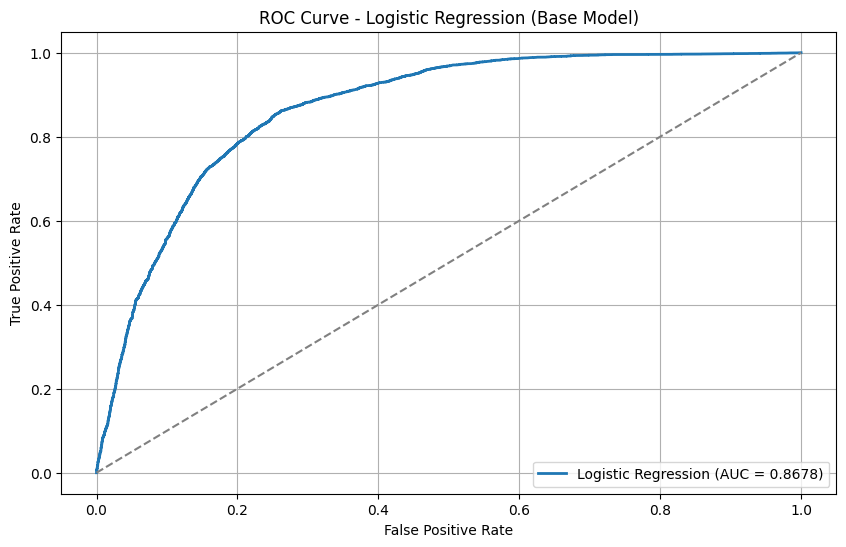

In [32]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities for ROC Curve
y_prob_logreg = log_reg_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logreg)
roc_auc = auc(fpr, tpr)

# Plot ROC-AUC Curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, lw=2, label='Logistic Regression (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - Logistic Regression (Base Model)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

##### LR - Hyperparameter Tuning

In [33]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression Model
logreg = LogisticRegression()

param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
    'max_iter': [50, 100, 200],
}

search_logreg = GridSearchCV(logreg, param_grid_logreg, cv=5, n_jobs=-1)

# Fit the model
search_logreg.fit(X_train_scaled, y_train)

# Predict using the best model
best_logreg = search_logreg.best_estimator_
y_pred_logreg = best_logreg.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_logreg)
confusion = confusion_matrix(y_test, y_pred_logreg)
report = classification_report(y_test, y_pred_logreg)

# Display results
print(f"Confusion Matrix (After Tuning):\n {confusion}")
print(f"\n📊Classification Report:\n{report}")

# Best parameters and best score
print("✅Best Hyperparameters for LOGISTIC REGRESSION: ")
for param, value in search_logreg.best_params_.items():
    print(f"  {param.capitalize()}: {value}")

print(f"\nBest Cross-Validation Score: {search_logreg.best_score_:.4f}")
print(f"Accuracy (After Tuning): {accuracy:.4f}")

Confusion Matrix (After Tuning):
 [[3754 1173]
 [1090 5380]]

📊Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.77      4927
           1       0.82      0.83      0.83      6470

    accuracy                           0.80     11397
   macro avg       0.80      0.80      0.80     11397
weighted avg       0.80      0.80      0.80     11397

✅Best Hyperparameters for LOGISTIC REGRESSION: 
  C: 0.01
  Max_iter: 50
  Penalty: l2
  Solver: saga

Best Cross-Validation Score: 0.7928
Accuracy (After Tuning): 0.8014


##### LR - Learning Curve (After Tune)

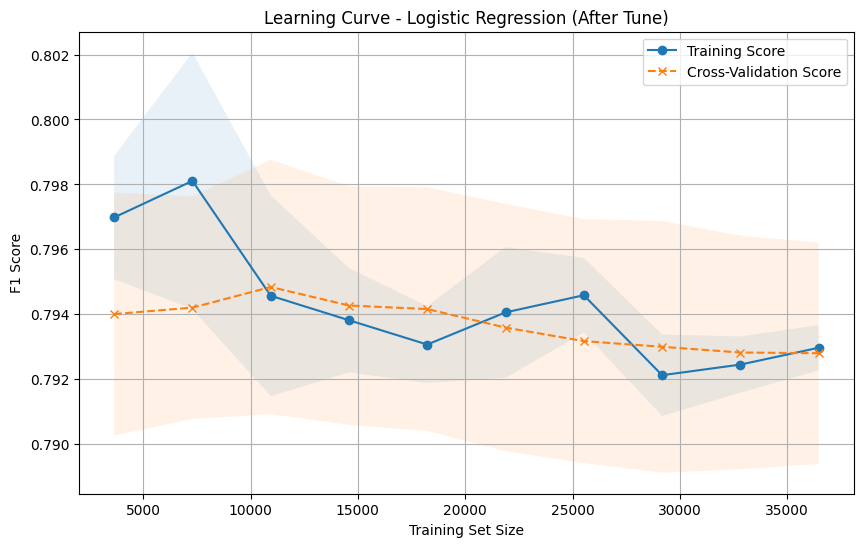

In [34]:
# After Hyperparameter Tuning Model (Best model from GridSearchCV)
train_sizes, train_scores, test_scores = learning_curve(
    best_logreg, 
    X_train_scaled, 
    y_train, 
    cv=5, 
    n_jobs=-1, 
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
)

# Calculate mean and std for train and test scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Plot Learning Curve for tuned model
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label=f'Training Score', linestyle='-', marker='o')
plt.plot(train_sizes, test_mean, label=f'Cross-Validation Score', linestyle='--', marker='x')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.title('Learning Curve - Logistic Regression (After Tune)')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()

##### LR - ROC-AUC (After Tune)

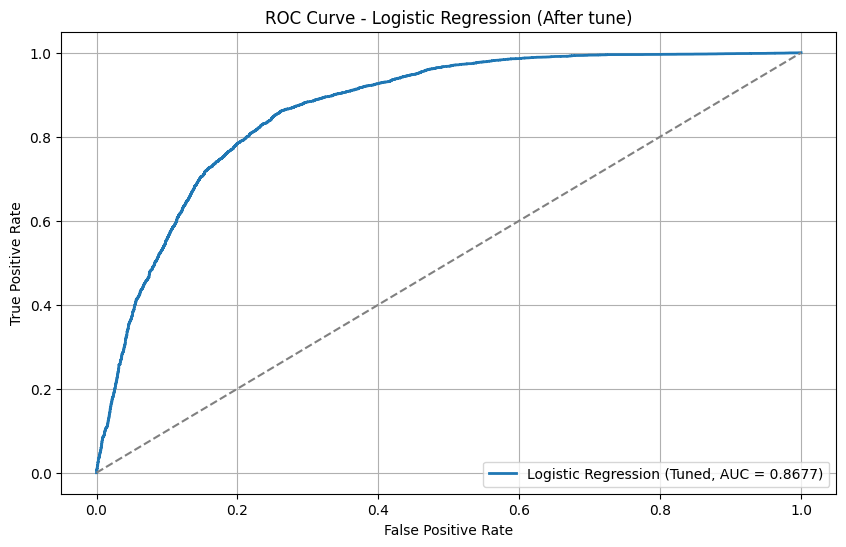

In [35]:
# Predict probabilities for ROC Curve (tuned model)
y_prob_best_logreg = best_logreg.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve for the tuned model
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_prob_best_logreg)
roc_auc_best = auc(fpr_best, tpr_best)

# Plot ROC-AUC Curve for tuned model
plt.figure(figsize=(10, 6))
plt.plot(fpr_best, tpr_best, lw=2, label='Logistic Regression (Tuned, AUC = %0.4f)' % roc_auc_best)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - Logistic Regression (After tune)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


##### LR - Feature Importance

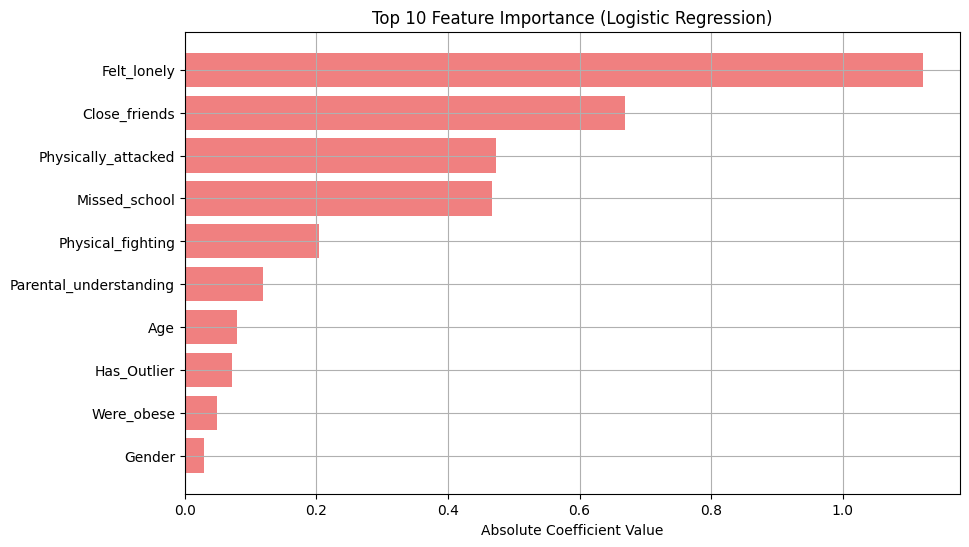

In [36]:
# Get feature coefficients
coefficients = best_logreg.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients
})

# Sort by absolute value of the coefficients
feature_importance['Absolute Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute Coefficient', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][:10], feature_importance['Absolute Coefficient'][:10], color='lightcoral')
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 10 Feature Importance (Logistic Regression)')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


#### (6.2) Random Forest (RF)

In [208]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)
confusion = confusion_matrix(y_test, y_pred_rf)
report = classification_report(y_test, y_pred_rf)

# Print results
print(f"Confusion Matrix:\n {confusion}")
print(f"\n📊 Classification Report:\n{report}")
print(f"✅ Accuracy: {accuracy:.4f}")


Confusion Matrix:
 [[3809 1118]
 [ 842 5628]]

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.77      0.80      4927
           1       0.83      0.87      0.85      6470

    accuracy                           0.83     11397
   macro avg       0.83      0.82      0.82     11397
weighted avg       0.83      0.83      0.83     11397

✅ Accuracy: 0.8280


##### RF - Learning Curve (Base)

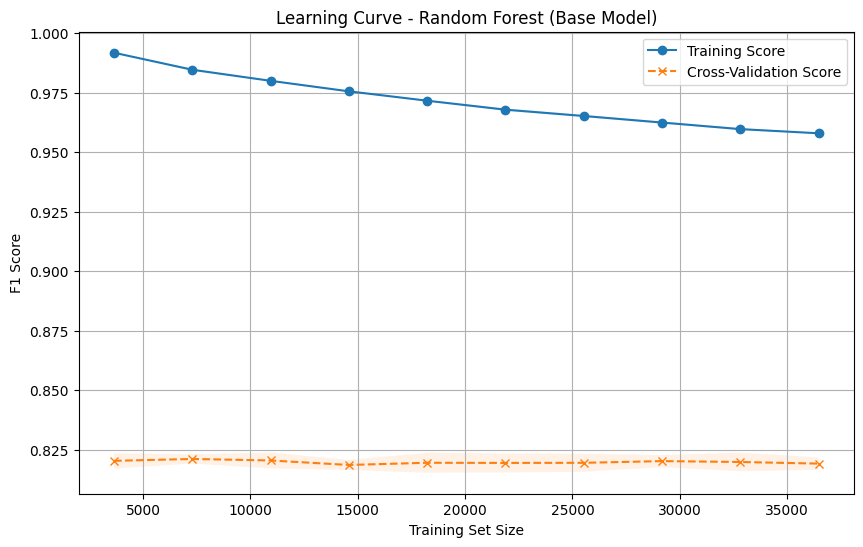

In [ ]:
# Random Forest Base Model Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, 
    X_train, 
    y_train, 
    cv=5, 
    n_jobs=-1,
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
)

# Calculate mean and std for train and test scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Plot Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label=f'Training Score', linestyle='-', marker='o')
plt.plot(train_sizes, test_mean, label=f'Cross-Validation Score', linestyle='--', marker='x')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.title('Learning Curve - Random Forest (Base Model)')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()


##### RF - ROU-AUC (Base)

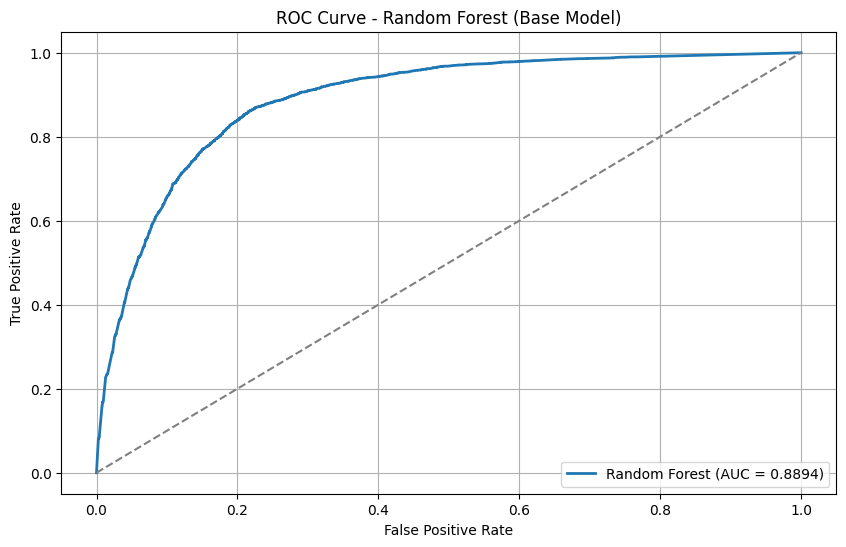

In [ ]:
# Predict probabilities for ROC Curve
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC-AUC Curve for Base Model
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, lw=2, label='Random Forest (AUC = %0.4f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - Random Forest (Base Model)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

##### RF - Hyperparameter Tuning 

In [ ]:
rf = RandomForestClassifier()

param_grid_rf = {
    'n_estimators': [50, 100, 200, 300],      
    'max_depth': [10, 20, 30, None],          
    'min_samples_split': [2, 5, 10],          
    'min_samples_leaf': [1, 2, 4],            
    'bootstrap': [True, False],               
}

# Perform GridSearchCV
search_rf = GridSearchCV(rf, param_grid_rf, cv=5, n_jobs=-1)

# Fit the model
search_rf.fit(X_train, y_train)

# Predict using the best model
best_rf = search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_rf)
confusion = confusion_matrix(y_test, y_pred_rf)
report = classification_report(y_test, y_pred_rf)

# Display results
print(f"confusion_matrix (After Tuning):\n {confusion}")
print(f"\n📊Classification Report:\n{report}")

print("✅Best Hyperparameters for RANDOM FOREST: ")
for param, value in search_rf.best_params_.items():
    print(f"  {param.capitalize()}: {value}")

print(f"\nBest Cross-Validation Score: {search_rf.best_score_:.4f}")
print(f"Accuracy (After Tuning): {accuracy:.4f}")


confusion_matrix (After Tuning):
 [[3875 1052]
 [ 769 5701]]

📊Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      4927
           1       0.84      0.88      0.86      6470

    accuracy                           0.84     11397
   macro avg       0.84      0.83      0.84     11397
weighted avg       0.84      0.84      0.84     11397

✅Best Hyperparameters for RANDOM FOREST: 
  Bootstrap: True
  Max_depth: 10
  Min_samples_leaf: 1
  Min_samples_split: 5
  N_estimators: 50

Best Cross-Validation Score: 0.8381
Accuracy (After Tuning): 0.8402


##### RF - Learning Curve (After Tune)

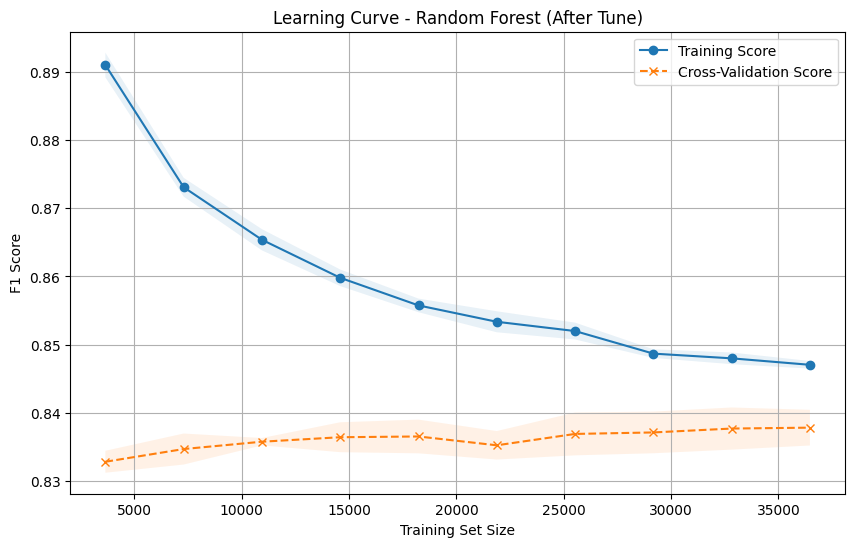

In [ ]:
# After Hyperparameter Tuning (Best Random Forest Model from GridSearchCV)
train_sizes, train_scores, test_scores = learning_curve(
    best_rf, 
    X_train, 
    y_train, 
    cv=5, 
    n_jobs=-1,
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
)

# Calculate mean and std for train and test scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Plot Learning Curve for Tuned Model
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label=f'Training Score', linestyle='-', marker='o')
plt.plot(train_sizes, test_mean, label=f'Cross-Validation Score', linestyle='--', marker='x')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.title('Learning Curve - Random Forest (After Tune)')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()


##### RF - ROU-AUC (After Tune)

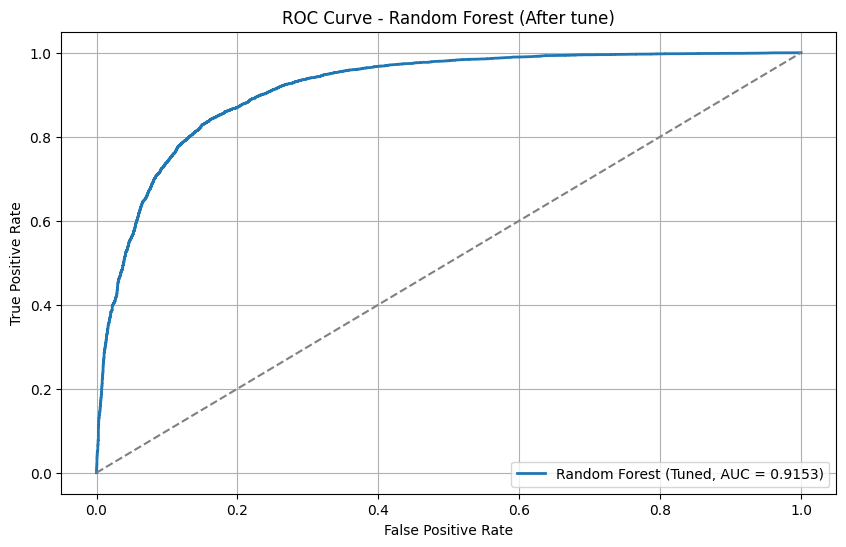

In [213]:
# Predict probabilities for ROC Curve (Tuned Model)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

# Compute ROC curve for Tuned Model
fpr_best_rf, tpr_best_rf, thresholds_best_rf = roc_curve(y_test, y_prob_best_rf)
roc_auc_best_rf = auc(fpr_best_rf, tpr_best_rf)

# Plot ROC-AUC Curve for Tuned Model
plt.figure(figsize=(10, 6))
plt.plot(fpr_best_rf, tpr_best_rf, lw=2, label='Random Forest (Tuned, AUC = %0.4f)' % roc_auc_best_rf)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - Random Forest (After tune)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


##### RF - Feature Importance

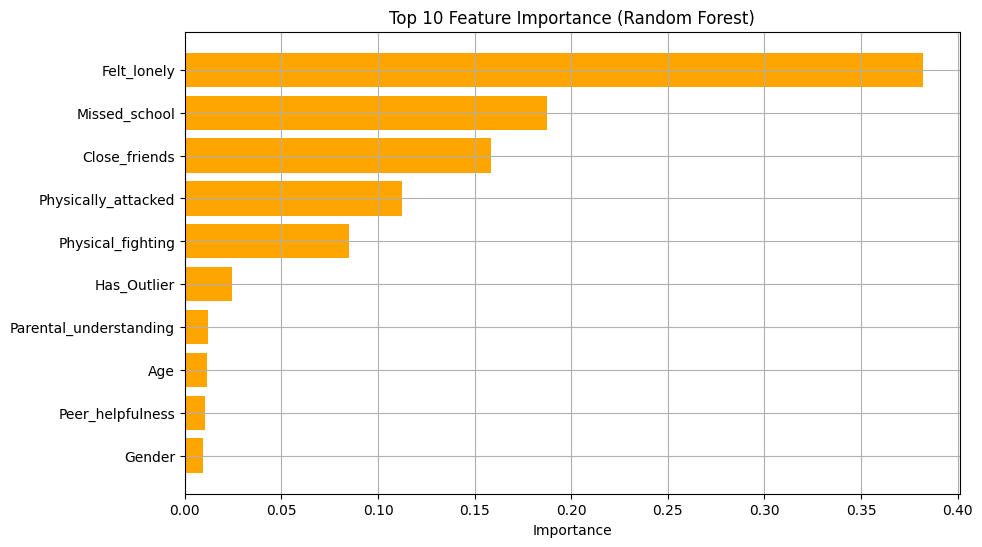

In [ ]:
# Get feature importance from the tuned model
feature_importance_rf = best_rf.feature_importances_

# Create a dataframe for feature names and their corresponding importance
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance_rf
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10], color='orange')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


#### (6.3) SVM

In [37]:
from sklearn.svm import SVC

# SVM Model (use scaled data)
svm_model = SVC(kernel="linear", probability=True)
svm_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_svm = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred_svm)
confusion = confusion_matrix(y_test, y_pred_svm)
report = classification_report(y_test, y_pred_svm)

# Print results
print(f"Confusion Matrix:\n {confusion}")
print(f"\n📊 Classification Report:\n{report}")
print(f"✅ Accuracy: {accuracy:.4f}")

Confusion Matrix:
 [[3661 1266]
 [ 961 5509]]

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.74      0.77      4927
           1       0.81      0.85      0.83      6470

    accuracy                           0.80     11397
   macro avg       0.80      0.80      0.80     11397
weighted avg       0.80      0.80      0.80     11397

✅ Accuracy: 0.8046


##### SVM - Learning Curve (Base)

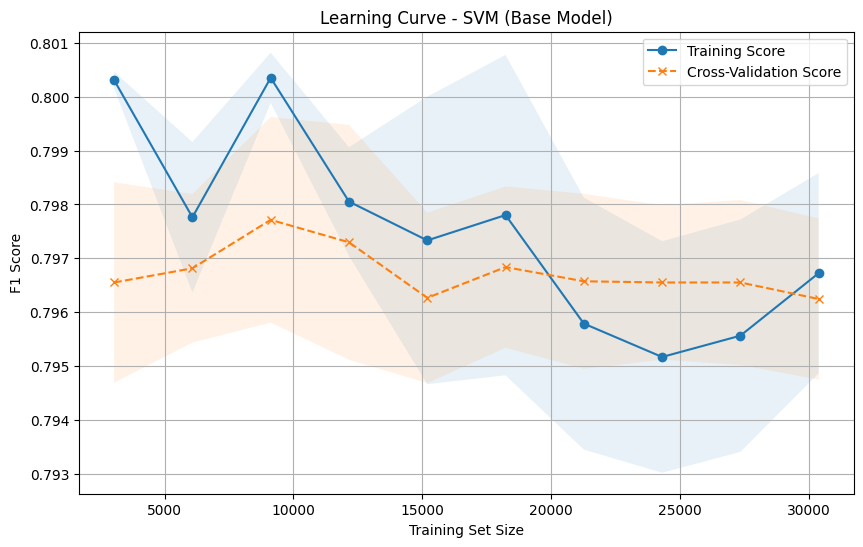

In [38]:
# Learning Curve for SVM (Base Model)
train_sizes, train_scores, test_scores = learning_curve(
    svm_model, 
    X_train_scaled, 
    y_train, 
    cv=3, 
    n_jobs=-1,
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
)

# Calculate mean and std for train and test scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Plot Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label=f'Training Score', linestyle='-', marker='o')
plt.plot(train_sizes, test_mean, label=f'Cross-Validation Score', linestyle='--', marker='x')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.title('Learning Curve - SVM (Base Model)')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()

##### SVM - ROC-AUC (Base)

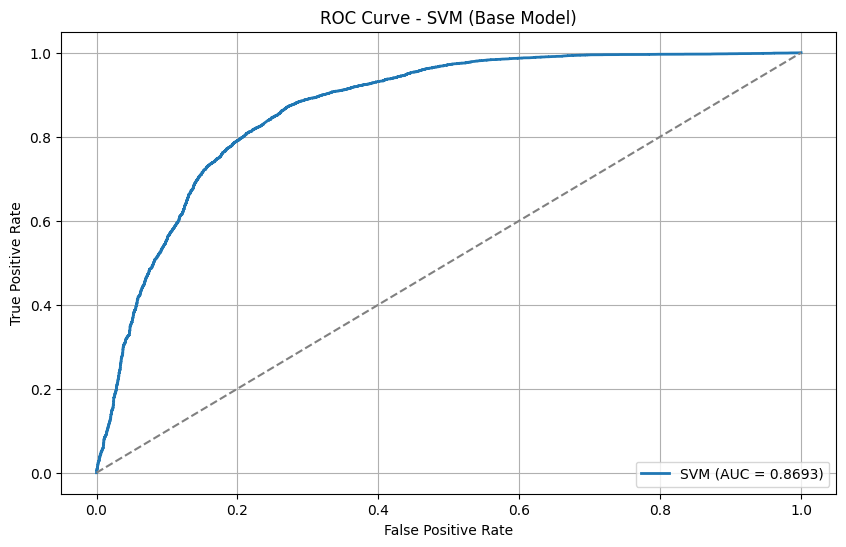

In [39]:
# Predict probabilities for ROC Curve (Base Model)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Plot ROC-AUC Curve for Base Model
plt.figure(figsize=(10, 6))
plt.plot(fpr_svm, tpr_svm, lw=2, label='SVM (AUC = %0.4f)' % roc_auc_svm)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - SVM (Base Model)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

##### SVM - Hyperparameter Tuning

In [ ]:
# SVM Model
svm =  SVC(probability=True)

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.1, 1],
}

search_svm = RandomizedSearchCV(svm, param_grid_svm, n_iter=10, 
                                cv=3, n_jobs=-1, random_state=42)

# Fit the model
search_svm.fit(X_train_scaled, y_train)

# Predict using the best model
best_svm = search_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_svm)
confusion = confusion_matrix(y_test, y_pred_svm)
report = classification_report(y_test, y_pred_svm)

# Display results
print(f"Confusion Matrix (After Tuning):\n {confusion}")
print(f"\n📊Classification Report:\n{report}")

print("✅Best Hyperparameters for SVM : ")
for param, value in search_svm.best_params_.items():
    print(f"  {param.capitalize()}: {value}")

print(f"\nBest Cross-Validation Score: {search_svm.best_score_:.4f}")
print(f"Accuracy (After Tuning): {accuracy:.4f}")


Confusion Matrix (After Tuning):
 [[3792 1135]
 [ 720 5750]]

📊Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.77      0.80      4927
           1       0.84      0.89      0.86      6470

    accuracy                           0.84     11397
   macro avg       0.84      0.83      0.83     11397
weighted avg       0.84      0.84      0.84     11397

✅Best Hyperparameters for SVM : 
  Kernel: rbf
  Gamma: 0.1
  C: 10

Best Cross-Validation Score: 0.8296
Accuracy (After Tuning): 0.8372


##### SVM - Learning Curve (After Tune)

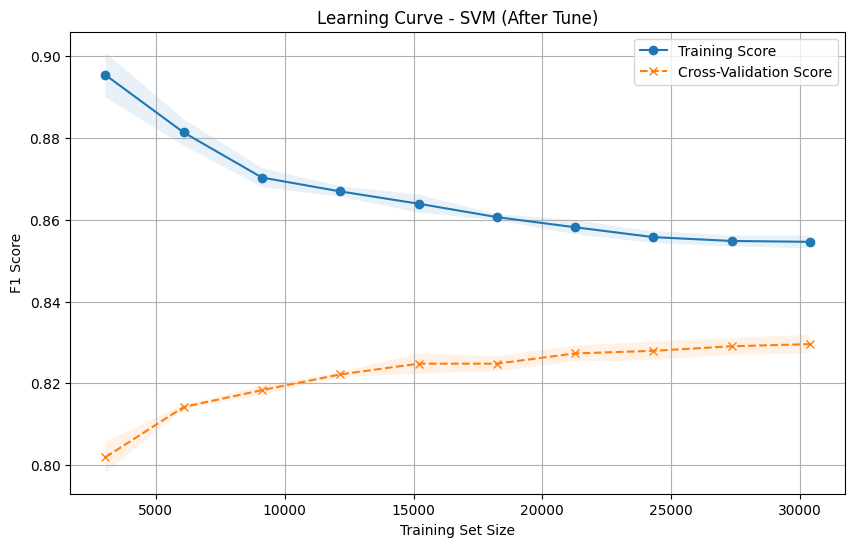

In [47]:
# Learning Curve for Tuned SVM
train_sizes, train_scores, test_scores = learning_curve(
    best_svm, 
    X_train_scaled, 
    y_train, 
    cv=3, 
    n_jobs=-1,
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
)

# Calculate mean and std for train and test scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Plot Learning Curve for Tuned Model
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label=f'Training Score', linestyle='-', marker='o')
plt.plot(train_sizes, test_mean, label=f'Cross-Validation Score', linestyle='--', marker='x')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.title('Learning Curve - SVM (After Tune)')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()

##### SVM - ROC-AUC (After Tune)

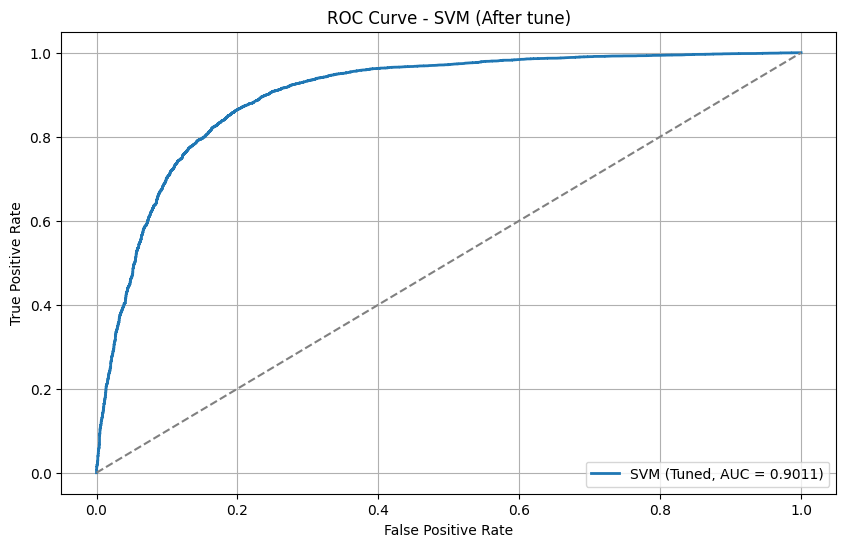

In [48]:
# Predict probabilities for ROC Curve (Tuned Model)
y_prob_best_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve for Tuned Model
fpr_best_svm, tpr_best_svm, thresholds_best_svm = roc_curve(y_test, y_prob_best_svm)
roc_auc_best_svm = auc(fpr_best_svm, tpr_best_svm)

# Plot ROC-AUC Curve for Tuned Model
plt.figure(figsize=(10, 6))
plt.plot(fpr_best_svm, tpr_best_svm, lw=2, label='SVM (Tuned, AUC = %0.4f)' % roc_auc_best_svm)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - SVM (After tune)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

##### SVM - Feature Importance

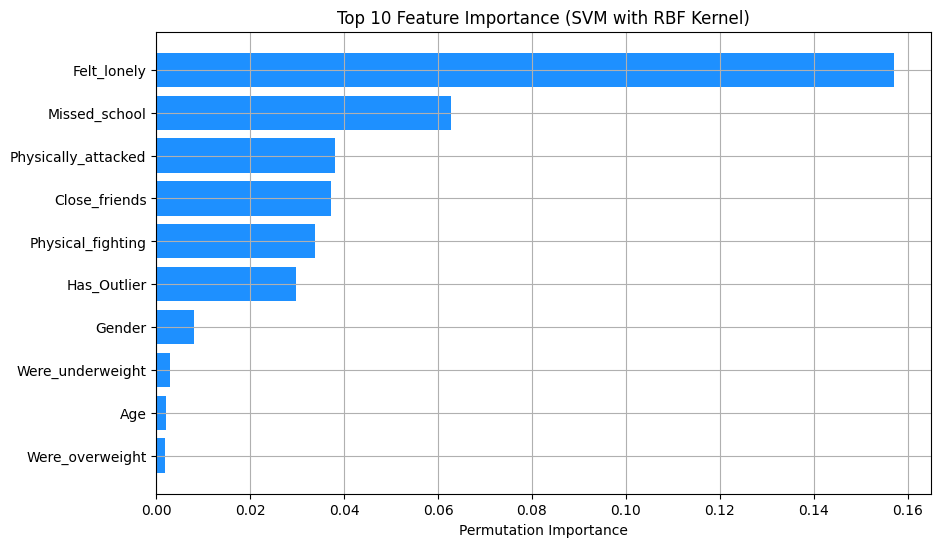

In [52]:
from sklearn.inspection import permutation_importance

# Get permutation importance
result = permutation_importance(best_svm, X_test_scaled, y_test, n_repeats=10, random_state=42)

# Create a DataFrame for feature importance
feature_importance_svm = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': result.importances_mean 
})

# Sort the features by importance
feature_importance_svm = feature_importance_svm.sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_svm['Feature'][:10], feature_importance_svm['Importance'][:10], color='dodgerblue')
plt.xlabel('Permutation Importance')
plt.title('Top 10 Feature Importance (SVM with RBF Kernel)')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

#### (6.4) XGBoost (XGB)

In [222]:
from xgboost import XGBClassifier

# XGBoost Model
xgboost_model = XGBClassifier(eval_metric="mlogloss", random_state=42)
xgboost_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_xgboost = xgboost_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_xgboost)
confusion = confusion_matrix(y_test, y_pred_xgboost)
report = classification_report(y_test, y_pred_xgboost)

# Print results
print(f"Confusion Matrix:\n {confusion}")
print(f"\n📊 Classification Report:\n{report}")
print(f"✅ Accuracy: {accuracy:.4f}")

Confusion Matrix:
 [[3953  974]
 [ 823 5647]]

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      4927
           1       0.85      0.87      0.86      6470

    accuracy                           0.84     11397
   macro avg       0.84      0.84      0.84     11397
weighted avg       0.84      0.84      0.84     11397

✅ Accuracy: 0.8423


##### XGBoost - Learning Curve (Base)

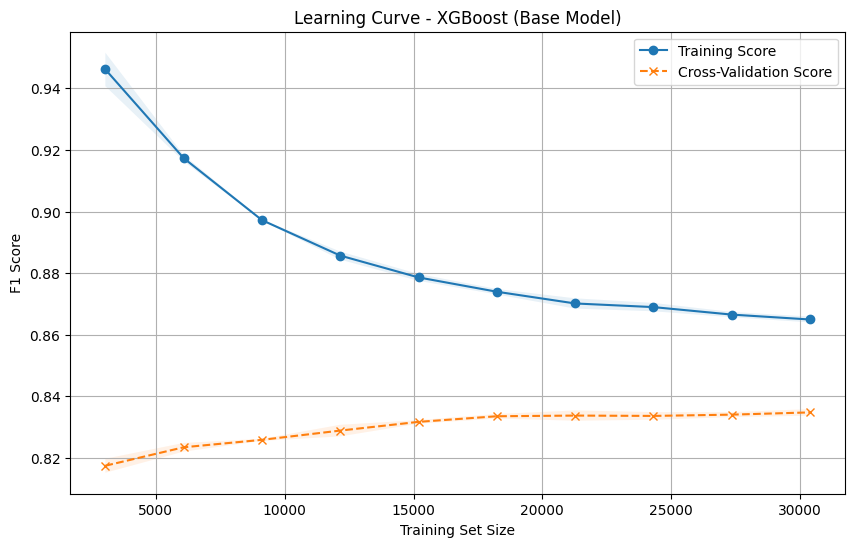

In [223]:
# Learning Curve for XGBoost (Base Model)
train_sizes, train_scores, test_scores = learning_curve(
    xgboost_model, 
    X_train, 
    y_train, 
    cv=3, 
    n_jobs=-1,
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
)

# Calculate mean and std for train and test scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Plot Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label=f'Training Score', linestyle='-', marker='o')
plt.plot(train_sizes, test_mean, label=f'Cross-Validation Score', linestyle='--', marker='x')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.title('Learning Curve - XGBoost (Base Model)')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()

##### XGBoost - ROC-AUC (Base)

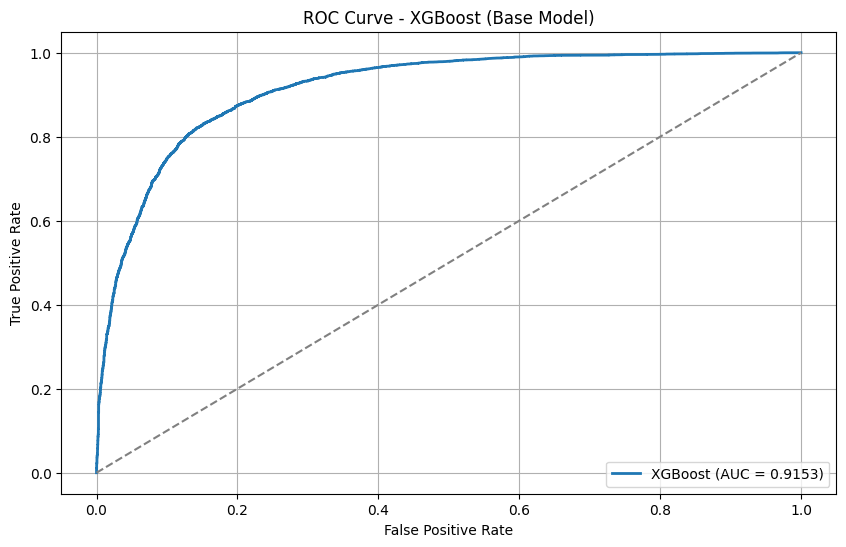

In [224]:
# Predict probabilities for ROC Curve (Base Model)
y_prob_xgb = xgboost_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC-AUC Curve for Base Model
plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb, tpr_xgb, lw=2, label='XGBoost (AUC = %0.4f)' % roc_auc_xgb)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - XGBoost (Base Model)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

##### XGBoost - Hyperparameter Tuning

In [238]:
from sklearn.model_selection import RandomizedSearchCV

# XGBoost Model
xgb = XGBClassifier()

param_grid_xgb = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 6, 10, 15],
    'learning_rate': [0.01, 0.1, 0.2, 0.5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5],
}

# Perform RandomizedSearchCV
search_xgb = RandomizedSearchCV(xgb, param_grid_xgb, n_iter=10, 
                                cv=5, n_jobs=-1, random_state=42)

# Fit the model
search_xgb.fit(X_train, y_train)

# Predict using the best model
best_xgb = search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_xgb)
confusion = confusion_matrix(y_test, y_pred_xgb)
report = classification_report(y_test, y_pred_xgb)

# Display results
print(f"Confusion Matrix (After Tuning):\n{confusion}")
print(f"\n📊Classification Report:\n{report}")

print("✅Best Hyperparameters for XGBoost: ")
for param, value in search_xgb.best_params_.items():
    print(f"  {param.capitalize()}: {value}")

print(f"\nBest Cross-Validation Score: {search_xgb.best_score_:.4f}")
print(f"Accuracy (After Tuning): {accuracy:.4f}")

Confusion Matrix (After Tuning):
[[3927 1000]
 [ 785 5685]]

📊Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      4927
           1       0.85      0.88      0.86      6470

    accuracy                           0.84     11397
   macro avg       0.84      0.84      0.84     11397
weighted avg       0.84      0.84      0.84     11397

✅Best Hyperparameters for XGBoost: 
  Subsample: 0.6
  N_estimators: 300
  Max_depth: 3
  Learning_rate: 0.1
  Gamma: 0.5
  Colsample_bytree: 1.0

Best Cross-Validation Score: 0.8395
Accuracy (After Tuning): 0.8434


##### XGBoost - Learning Curve (After Tune)

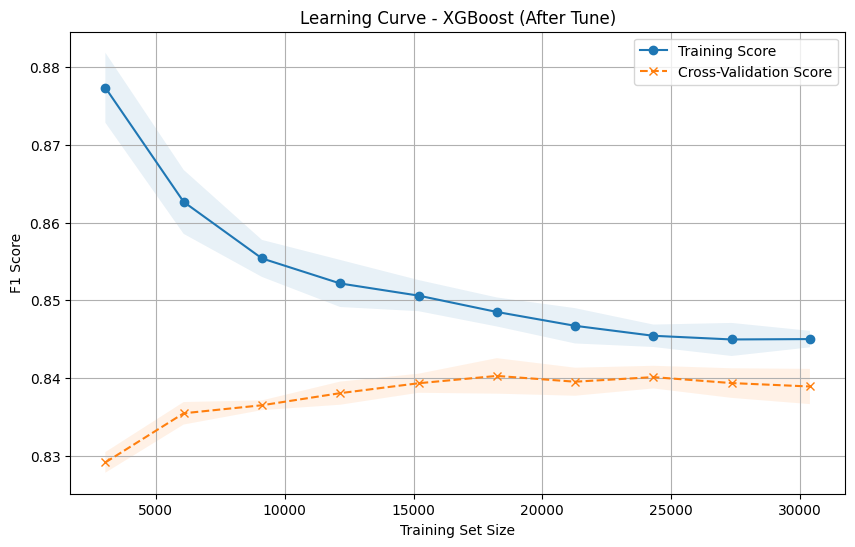

In [239]:
# Learning Curve for Tuned XGBoost
train_sizes, train_scores, test_scores = learning_curve(
    best_xgb, X_train, y_train, cv=3, n_jobs=-1,
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
)

# Calculate mean and std for train and test scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Plot Learning Curve for Tuned Model
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label=f'Training Score', linestyle='-', marker='o')
plt.plot(train_sizes, test_mean, label=f'Cross-Validation Score', linestyle='--', marker='x')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.title('Learning Curve - XGBoost (After Tune)')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()

##### XGBoost - ROC-AUC (After Tune)

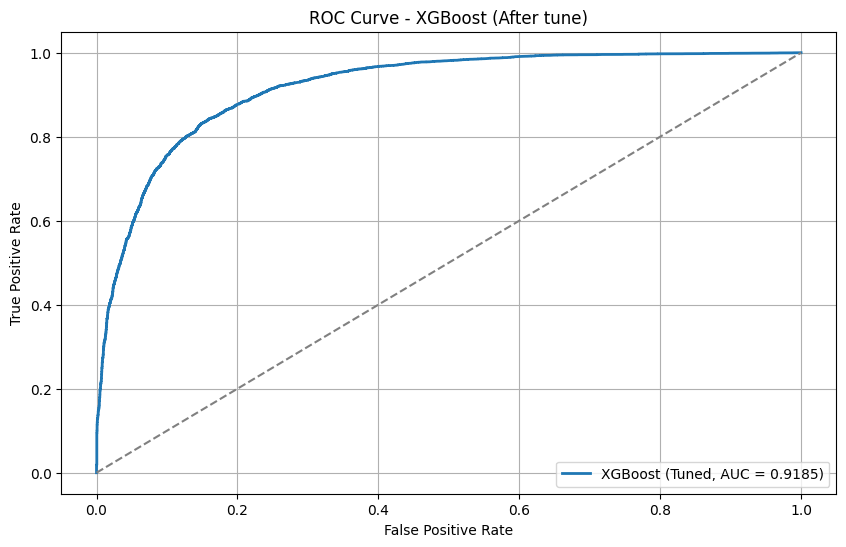

In [240]:
# Predict probabilities for ROC Curve (Tuned Model)
y_prob_best_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Compute ROC curve for Tuned Model
fpr_best_xgb, tpr_best_xgb, thresholds_best_xgb = roc_curve(y_test, y_prob_best_xgb)
roc_auc_best_xgb = auc(fpr_best_xgb, tpr_best_xgb)

# Plot ROC-AUC Curve for Tuned Model
plt.figure(figsize=(10, 6))
plt.plot(fpr_best_xgb, tpr_best_xgb, lw=2, label='XGBoost (Tuned, AUC = %0.4f)' % roc_auc_best_xgb)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - XGBoost (After tune)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

##### XGBoost - Feature Importance

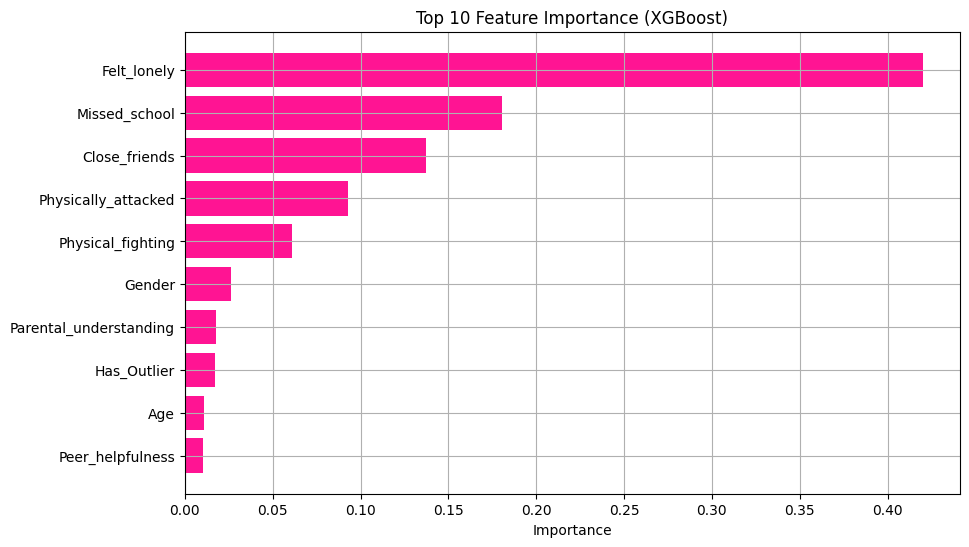

In [241]:
# Get feature importance from the tuned XGBoost model
feature_importance_xgb = best_xgb.feature_importances_

# Create a dataframe for feature names and their corresponding importance
feature_importance_df_xgb = pd.DataFrame({
    'Feature': X_train.columns,   
    'Importance': feature_importance_xgb   
})

# Sort by importance (descending order)
feature_importance_df_xgb = feature_importance_df_xgb.sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df_xgb['Feature'][:10], feature_importance_df_xgb['Importance'][:10], color='deeppink')
plt.xlabel('Importance')   
plt.title('Top 10 Feature Importance (XGBoost)')  
plt.gca().invert_yaxis()   
plt.grid(True)             
plt.show()


#### (6.5) Best Model

In [ ]:
# Compare performance metrics (accuracy and AUC) for each model
model_performance = {
    'Logistic Regression': accuracy_score(y_test, search_logreg.best_estimator_.predict(X_test)),
    'Random Forest': accuracy_score(y_test, search_rf.best_estimator_.predict(X_test)),
    'SVM': accuracy_score(y_test, search_svm.best_estimator_.predict(X_test)),
    'XGBoost': accuracy_score(y_test, search_xgb.best_estimator_.predict(X_test))
}

best_model_name = max(model_performance, key=model_performance.get)
print(f"Best model: {best_model_name}")
print(f"Accuracy: {model_performance[best_model_name]:.4f}\n")

Best model: XGBoost
Accuracy: 0.8434



c:\Users\Yap\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## 7. Model Deployment

In [ ]:
import joblib

joblib.dump(best_xgb, 'Bullying_best_model.pkl')

['Bullying_model.pkl']